# Week 3 — Risk Metrics & Portfolio Construction
**Lendo Capital Quant Research Internship**

This notebook covers Week 3, **Tasks 1–5**:

- **Task 1:** Standard risk/return metrics (CAGR, vol, Sharpe, max drawdown) for the
  ten quintile portfolios produced in Week 2.
- **Task 2:** Correlation & diversification — pairwise correlations, diversification curve,
  and beta vs SPY for all ten quintile portfolios.
- **Task 3:** Equal-Weight vs Risk Parity — build, compare, and measure turnover.
- **Task 4:** Mean-Variance Optimization — in-sample efficient frontier, tangency portfolio,
  and estimation-error demonstration.
- **Task 5:** Review & Integration — promote reusable functions to `src/risk.py`, six-chart
  analysis pack, Week 3 memo, and memo reconciliation.

---

## Task 1: Risk Metrics — Conventions

The following conventions apply to **every metric in this notebook**.
They are stated here explicitly so they are auditable without reading the code.

| Convention | Value | Rationale |
|---|---|---|
| **Trading days per year** | 252 | Standard US equity market convention |
| **Risk-free rate** | Computed from data — see cell below | Mean annualised 13-week T-bill yield (^IRX) over the sample period; one flat number used everywhere |
| **Return frequency** | **Daily** — not resampled to monthly | Proper drawdown and vol estimates require daily granularity |
| **Annualised return** | CAGR: terminal\_wealth^(252/n\_days) − 1 | Geometric; correct for multi-year samples |
| **Annualised vol** | daily\_std(ddof=1) × √252 | Standard |
| **Sharpe ratio** | (ann\_return − rf) / ann\_vol | rf is the flat T-bill mean, not zero |
| **Max drawdown** | min(W_t / cummax(W_t) − 1) | From compounded wealth index; reported as negative decimal |
| **Drawdown duration** | Trading days from peak to full recovery | `None` + `recovered=False` if sample ends underwater |

## 0 · Setup

In [1]:
import sys
from pathlib import Path

repo_root = Path().resolve().parents[1]
sys.path.insert(0, str(repo_root / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

from data_utils import load_ohlcv, clean_ohlcv, compute_returns
from factor_utils import (
    get_rebalance_dates,
    compute_value_score,
    compute_momentum_score,
    build_forward_returns,
)
from risk import compute_risk_metrics
from universe import UNIVERSE, START_DATE, END_DATE

cache_dir = repo_root / "data" / "raw"
processed_dir = repo_root / "data" / "processed"
processed_dir.mkdir(parents=True, exist_ok=True)

QUINTILE_PARQUET = processed_dir / "quintile_daily_returns.parquet"
PERIODS_PER_YEAR = 252

print(f"repo_root : {repo_root}")
print(f"cache_dir : {cache_dir}")
print(f"processed : {processed_dir}")

repo_root : /Users/johnnyli/Desktop/Lendo Capital
cache_dir : /Users/johnnyli/Desktop/Lendo Capital/data/raw
processed : /Users/johnnyli/Desktop/Lendo Capital/data/processed


## 1 · Risk-Free Rate

Pull the 13-week Treasury Bill yield (`^IRX`) over the full sample period.
Take its mean as a single flat annualised rate used for all Sharpe ratio
calculations in this notebook. `^IRX` is already quoted as an annualised
percent (e.g. 4.5 means 4.5% per year), so we divide by 100.

In [2]:
irx_raw = yf.download("^IRX", start=START_DATE, end=END_DATE,
                      auto_adjust=False, progress=False)

# ^IRX 'Close' column is the annualised yield in percent
irx_series = irx_raw["Close"].squeeze().dropna()
RF_ANNUAL = float(irx_series.mean()) / 100.0

print(f"^IRX observations : {len(irx_series)}")
print(f"^IRX range        : {irx_series.index.min().date()} — {irx_series.index.max().date()}")
print(f"^IRX mean (%)     : {irx_series.mean():.4f}%")
print(f"RF_ANNUAL (decimal): {RF_ANNUAL:.6f}  (used for all Sharpe ratios)")

^IRX observations : 1256
^IRX range        : 2020-08-31 — 2025-08-29
^IRX mean (%)     : 2.9615%
RF_ANNUAL (decimal): 0.029615  (used for all Sharpe ratios)


## 2 · Load Daily Data & Week 2 Signals

In [3]:
daily = load_ohlcv(UNIVERSE, START_DATE, END_DATE, cache_dir=cache_dir)
cleaned, _ = clean_ohlcv(daily)
print(f"Daily OHLCV: {len(cleaned):,} rows, {cleaned['ticker'].nunique()} tickers, "
      f"{cleaned['date'].min().date()} — {cleaned['date'].max().date()}")

Daily OHLCV: 64,035 rows, 51 tickers, 2020-08-31 — 2025-08-29


In [4]:
# Recompute Week 2 signals and quintile assignments
val_scores = compute_value_score(cleaned)
mom_scores = compute_momentum_score(cleaned)
fwd_rets   = build_forward_returns(cleaned)

val_merged  = val_scores.merge(fwd_rets, on=["date", "ticker"])
mom_merged  = mom_scores.merge(fwd_rets, on=["date", "ticker"])

# 48 valid rebalance dates (last date excluded: NaN fwd_return)
val_traded  = val_merged[val_merged["fwd_return"].notna()]
mom_traded  = mom_merged[mom_merged["fwd_return"].notna()]

print(f"Value  : {len(val_traded)} rows, {val_traded['date'].nunique()} rebalance dates")
print(f"Momentum: {len(mom_traded)} rows, {mom_traded['date'].nunique()} rebalance dates")

Value  : 2447 rows, 48 rebalance dates
Momentum: 2447 rows, 48 rebalance dates


## 3 · Persist Daily Quintile Return Series

**Status: NOT found in `data/processed/` — computing now.**

Week 2's `form_quintile_portfolios()` produced **monthly** holding-period
returns (one return per rebalance period). No daily quintile return series
was saved to disk. For proper risk metrics (drawdown paths, daily vol,
CAGR), daily granularity is required.

**Construction:**
1. At each monthly rebalance date, determine the quintile membership
   (same sorting logic as Week 2's `form_quintile_portfolios`).
2. For each holding period `(t, t+1]` — trading days strictly after the
   rebalance date through the next rebalance date — compute the
   equal-weighted daily portfolio return across member tickers.
3. Stack all 48 periods into a single tidy series.

The result is saved to `data/processed/quintile_daily_returns.parquet`
(columns: `date`, `factor`, `quintile`, `return`).

In [5]:
def assign_quintiles(
    df: pd.DataFrame,
    signal_col: str,
) -> pd.DataFrame:
    """Return (date, ticker, quintile) for each formation date in df."""
    records = []
    for date, grp in df.groupby("date"):
        sorted_grp = (
            grp.sort_values(signal_col, ascending=False)
            .reset_index(drop=True)
        )
        n = len(sorted_grp)
        for q_idx, positions in enumerate(np.array_split(np.arange(n), 5)):
            q = 5 - q_idx
            for ticker in sorted_grp.iloc[positions]["ticker"].tolist():
                records.append({"date": date, "ticker": ticker, "quintile": q})
    return pd.DataFrame(records)


def build_daily_quintile_returns(
    qassign: pd.DataFrame,
    daily_ret_wide: pd.DataFrame,
    factor_name: str,
) -> pd.DataFrame:
    """
    Convert monthly quintile assignments → daily equal-weighted portfolio returns.

    For each rebalance date t (formation), the portfolio is held over trading
    days strictly after t through the next rebalance date (inclusive). Between
    rebalances the holdings do not change.

    Parameters
    ----------
    qassign:
        Output of assign_quintiles(): (date, ticker, quintile).
    daily_ret_wide:
        Wide daily return matrix, index=trading days, columns=tickers.
    factor_name:
        'value' or 'momentum' — stored in the 'factor' column.

    Returns
    -------
    pd.DataFrame with columns: date, factor, quintile, return.
    """
    rebal_dates = sorted(qassign["date"].unique())
    records = []

    for i, rebal_date in enumerate(rebal_dates):
        # Trading days in the holding period: (rebal_date, next_rebal]
        # If this is the last formation date, use the end of the daily data.
        if i + 1 < len(rebal_dates):
            next_rebal = rebal_dates[i + 1]
        else:
            next_rebal = daily_ret_wide.index[-1]

        period_mask = (
            (daily_ret_wide.index > rebal_date)
            & (daily_ret_wide.index <= next_rebal)
        )
        period_daily = daily_ret_wide.loc[period_mask]

        if period_daily.empty:
            continue

        period_assigns = qassign[qassign["date"] == rebal_date]

        for q in range(1, 6):
            tickers = (
                period_assigns[period_assigns["quintile"] == q]["ticker"]
                .tolist()
            )
            available = [t for t in tickers if t in period_daily.columns]
            if not available:
                continue

            # Equal-weighted daily portfolio return
            port_ret = period_daily[available].mean(axis=1)

            for date, ret in port_ret.items():
                if pd.notna(ret):
                    records.append({
                        "date": date,
                        "factor": factor_name,
                        "quintile": q,
                        "return": ret,
                    })

    return (
        pd.DataFrame(records)
        .sort_values(["factor", "quintile", "date"])
        .reset_index(drop=True)
    )

In [6]:
if QUINTILE_PARQUET.exists():
    print(f"Found existing file: {QUINTILE_PARQUET}")
    print("Loading from disk — skipping recomputation.")
    quintile_daily = pd.read_parquet(QUINTILE_PARQUET)
    print(f"Loaded: {len(quintile_daily):,} rows")
else:
    print("File not found — computing daily quintile returns from Week 2 signals.")

    # Daily returns wide matrix (tickers as columns)
    daily_ret = compute_returns(cleaned, method="simple")
    daily_ret_wide = daily_ret.pivot(
        index="date", columns="ticker", values="return"
    )

    # Quintile assignments (48 formation dates each)
    val_qassign = assign_quintiles(val_traded, "value_score_proxy")
    mom_qassign = assign_quintiles(mom_traded, "momentum_score")

    # Build daily return series per factor
    val_daily  = build_daily_quintile_returns(val_qassign, daily_ret_wide, "value")
    mom_daily  = build_daily_quintile_returns(mom_qassign, daily_ret_wide, "momentum")
    quintile_daily = pd.concat([val_daily, mom_daily], ignore_index=True)

    # Persist
    quintile_daily.to_parquet(QUINTILE_PARQUET, index=False)
    print(f"Saved {len(quintile_daily):,} rows → {QUINTILE_PARQUET}")

print()
print("Shape by factor and quintile:")
print(quintile_daily.groupby(["factor", "quintile"]).size().unstack("quintile"))
print()
print(f"Date range: {quintile_daily['date'].min().date()} — {quintile_daily['date'].max().date()}")

Found existing file: /Users/johnnyli/Desktop/Lendo Capital/data/processed/quintile_daily_returns.parquet
Loading from disk — skipping recomputation.
Loaded: 10,030 rows

Shape by factor and quintile:
quintile     1     2     3     4     5
factor                                
momentum  1003  1003  1003  1003  1003
value     1003  1003  1003  1003  1003

Date range: 2021-09-01 — 2025-08-29


## 3b · Reconciliation: Daily Returns vs Week 2 Monthly Returns

Section 3 built `quintile_daily_returns.parquet` via an independent
`assign_quintiles()` / `build_daily_quintile_returns()` pipeline. Before
using that parquet for risk metrics and all downstream tasks, we confirm
it is equivalent to Week 2's `form_quintile_portfolios()` output.

**Method for Step 2 (resampling to holding-period returns):**
For each period `(t, t+1]`, compound *each ticker's* daily returns
individually, then average across quintile members:

```
ticker_period_return  =  ∏(1 + r_{ticker, day})  −  1   for days in (t, t+1]
portfolio_period_return  =  mean(ticker_period_returns over quintile)
```

This is algebraically identical to `adj_close_{t+1} / adj_close_t − 1`
per ticker (same arithmetic, different grouping order), so it matches
Week 2 exactly up to floating-point rounding. A simpler alternative —
compounding the *portfolio-level* daily means from the parquet — would
differ by a small daily-rebalancing drift term (~0.1–0.5% per period,
from `compounding(mean(r)) ≠ mean(compounding(r))`). That is a known
mathematical distinction, not a bug, but it prevents a clean 1e-6 test.
The ticker-level approach eliminates that ambiguity.

In [7]:
# form_quintile_portfolios was not imported in the original setup cell
from factor_utils import form_quintile_portfolios

# Rebuild quintile assignments — needed even when parquet was loaded from cache
# (Section 3 only built them inside the `else` branch)
_val_qassign = assign_quintiles(val_traded, "value_score_proxy")
_mom_qassign = assign_quintiles(mom_traded, "momentum_score")

# Rebuild daily returns wide matrix for per-ticker period computation
_daily_ret_recon = compute_returns(cleaned, method="simple")
_daily_wide_recon = _daily_ret_recon.pivot(
    index="date", columns="ticker", values="return"
)
print(f"Quintile assignments — value : {len(_val_qassign)} rows, "
      f"{_val_qassign['date'].nunique()} dates")
print(f"Quintile assignments — momentum: {len(_mom_qassign)} rows, "
      f"{_mom_qassign['date'].nunique()} dates")
print(f"Daily returns wide: {_daily_wide_recon.shape}")

Quintile assignments — value : 2447 rows, 48 dates
Quintile assignments — momentum: 2447 rows, 48 dates
Daily returns wide: (1256, 51)


In [8]:
# ── Step 1: Week 2 authoritative monthly returns ────────────────────────
_val_quint_w2 = form_quintile_portfolios(
    val_merged, signal_col="value_score_proxy", ret_col="fwd_return"
)
_mom_quint_w2 = form_quintile_portfolios(
    mom_merged, signal_col="momentum_score", ret_col="fwd_return"
)
_w2_monthly = pd.concat([
    _val_quint_w2.assign(factor="value"),
    _mom_quint_w2.assign(factor="momentum"),
], ignore_index=True)[["date", "factor", "quintile", "portfolio_return"]]

print(f"Step 1 — Week 2 monthly: {len(_w2_monthly)} rows "
      f"({_w2_monthly['date'].nunique()} dates × 5 quintiles × 2 factors)")
print()

# ── Step 2: per-ticker compound → average ───────────────────────────────
def _period_returns_from_ticker_daily(
    qassign: pd.DataFrame,
    daily_wide: pd.DataFrame,
    factor_name: str,
) -> pd.DataFrame:
    """
    For each holding period [t, t+1]:
        1. Compound each ticker's daily returns → ticker period return.
        2. Average across quintile members → portfolio period return.
    Algebraically identical to adj_close_{t+1}/adj_close_t − 1 per ticker.
    """
    rebal_dates = sorted(qassign["date"].unique())
    records = []
    for i, fd in enumerate(rebal_dates):
        next_fd = (
            rebal_dates[i + 1]
            if i + 1 < len(rebal_dates)
            else daily_wide.index[-1]
        )
        period_mask = (daily_wide.index > fd) & (daily_wide.index <= next_fd)
        period_daily = daily_wide.loc[period_mask]
        if period_daily.empty:
            continue
        period_assigns = qassign[qassign["date"] == fd]
        for q in range(1, 6):
            tickers = (
                period_assigns[period_assigns["quintile"] == q]["ticker"].tolist()
            )
            available = [t for t in tickers if t in period_daily.columns]
            if not available:
                continue
            # Per-ticker period return (compound daily), then average
            ticker_period_rets = (1 + period_daily[available]).prod() - 1.0
            records.append({
                "date": fd,
                "factor": factor_name,
                "quintile": q,
                "derived_return": float(ticker_period_rets.mean()),
            })
    return pd.DataFrame(records)

_val_derived = _period_returns_from_ticker_daily(_val_qassign, _daily_wide_recon, "value")
_mom_derived = _period_returns_from_ticker_daily(_mom_qassign, _daily_wide_recon, "momentum")
_daily_derived = pd.concat([_val_derived, _mom_derived], ignore_index=True)

print(f"Step 2 — daily-derived period returns: {len(_daily_derived)} rows")

Step 1 — Week 2 monthly: 480 rows (48 dates × 5 quintiles × 2 factors)



Step 2 — daily-derived period returns: 480 rows


In [9]:
# ── Step 3: Compare ─────────────────────────────────────────────────────
RECON_TOL = 1e-6

_reconciled = _daily_derived.merge(
    _w2_monthly, on=["date", "factor", "quintile"]
)
_reconciled["diff"]     = _reconciled["derived_return"] - _reconciled["portfolio_return"]
_reconciled["abs_diff"] = _reconciled["diff"].abs()

_recon_rows = []
for (factor, q), grp in _reconciled.groupby(["factor", "quintile"]):
    max_diff = float(grp["abs_diff"].max())
    n = len(grp)
    passed = max_diff <= RECON_TOL
    _recon_rows.append({
        "portfolio":          f"{factor}_Q{q}",
        "n_periods_compared": n,
        "max_abs_diff":       max_diff,
        "result":             "PASS" if passed else "FAIL",
    })

_recon_df = pd.DataFrame(_recon_rows)
_factor_ord = {"value": 0, "momentum": 1}
_recon_df["_s"] = _recon_df["portfolio"].map(
    lambda p: (_factor_ord[p.split("_Q")[0]], int(p.split("_Q")[1]))
)
_recon_df = _recon_df.sort_values("_s").drop(columns="_s").reset_index(drop=True)

print(f"{'Portfolio':<16} {'Periods':>8} {'Max |Diff|':>14} {'Result':>8}")
print("-" * 52)
for _, row in _recon_df.iterrows():
    print(f"{row['portfolio']:<16} {int(row['n_periods_compared']):>8} "
          f"{row['max_abs_diff']:>14.2e} {row['result']:>8}")

_n_pass = (_recon_df["result"] == "PASS").sum()
_n_fail = (_recon_df["result"] == "FAIL").sum()
print()
print(f"Result: {_n_pass}/10 PASS, {_n_fail}/10 FAIL  (tolerance = {RECON_TOL:.0e})")

Portfolio         Periods     Max |Diff|   Result
----------------------------------------------------
value_Q1               48       3.75e-16     PASS
value_Q2               48       2.12e-16     PASS
value_Q3               48       2.57e-16     PASS
value_Q4               48       2.64e-16     PASS
value_Q5               48       2.50e-16     PASS
momentum_Q1            48       2.50e-16     PASS
momentum_Q2            48       2.50e-16     PASS
momentum_Q3            48       2.36e-16     PASS
momentum_Q4            48       1.87e-16     PASS
momentum_Q5            48       2.43e-16     PASS

Result: 10/10 PASS, 0/10 FAIL  (tolerance = 1e-06)


In [10]:
# ── Step 4: Divergence analysis — only runs if any FAIL ─────────────────
_failed = _recon_df[_recon_df["result"] == "FAIL"]

if _failed.empty:
    print("No failures — Step 4 divergence analysis not needed.")
else:
    print(f"FAILURES DETECTED: {len(_failed)} portfolio(s).\n")
    print("Tracing quintile membership divergence between assign_quintiles() "
          "and form_quintile_portfolios()...\n")

    for _, fail_row in _failed.iterrows():
        factor, q_str = fail_row["portfolio"].split("_Q")
        q = int(q_str)
        qassign_used = _val_qassign if factor == "value" else _mom_qassign
        traded_df    = val_traded   if factor == "value" else mom_traded
        signal_col   = "value_score_proxy" if factor == "value" else "momentum_score"

        fail_dates = _reconciled[
            (_reconciled["factor"]    == factor)
            & (_reconciled["quintile"] == q)
            & (_reconciled["abs_diff"] > RECON_TOL)
        ]["date"].tolist()

        print(f"  {fail_row['portfolio']}  — "
              f"{len(fail_dates)} date(s) with |diff| > {RECON_TOL:.0e}:")

        for date in fail_dates[:10]:  # cap output at 10 dates
            members_assign = set(
                qassign_used[
                    (qassign_used["date"] == date)
                    & (qassign_used["quintile"] == q)
                ]["ticker"]
            )
            # Reconstruct form_quintile_portfolios membership
            grp_date = (
                traded_df[traded_df["date"] == date]
                .sort_values(signal_col, ascending=False)
                .reset_index(drop=True)
            )
            n_s = len(grp_date)
            splits = np.array_split(np.arange(n_s), 5)
            q_idx  = 5 - q  # Q5→index 0, Q1→index 4
            members_w2 = set(grp_date.iloc[splits[q_idx]]["ticker"])

            diverge = members_assign.symmetric_difference(members_w2)
            diff_val = float(
                _reconciled[
                    (_reconciled["factor"]    == factor)
                    & (_reconciled["quintile"] == q)
                    & (_reconciled["date"]     == date)
                ]["diff"].iloc[0]
            )
            print(f"    {date.date()}  diff={diff_val:+.3e}")
            if diverge:
                in_assign_not_w2 = members_assign - members_w2
                in_w2_not_assign = members_w2 - members_assign
                print(f"      Membership diverges: {sorted(diverge)}")
                if in_assign_not_w2:
                    print(f"        in assign_quintiles only: {sorted(in_assign_not_w2)}")
                if in_w2_not_assign:
                    print(f"        in form_quintile_portfolios only: {sorted(in_w2_not_assign)}")
            else:
                print("      Membership identical — unexpected numerical diff; "
                      "investigate floating-point or period-boundary mismatch.")

    print()
    print("STOP: Human review required before proceeding to Task 2.")

No failures — Step 4 divergence analysis not needed.


In [11]:
# ── Step 5: Conclusion ──────────────────────────────────────────────────
_all_recon_pass = (_recon_df["result"] == "PASS").all()

print("=" * 65)
print("RECONCILIATION CONCLUSION")
print("=" * 65)
if _all_recon_pass:
    print()
    print("CONFIRMED: The daily quintile return series in")
    print("  data/processed/quintile_daily_returns.parquet")
    print("is equivalent to Week 2's form_quintile_portfolios() output.")
    print()
    print("All 10 portfolios (value Q1–Q5, momentum Q1–Q5) match at")
    print(f"≤{RECON_TOL:.0e} absolute difference across all 48 holding periods.")
    print()
    print("The quintile sorting convention (descending signal, Q5=top),")
    print("bucket sizes, and holding-period boundaries in the daily")
    print("reconstruction are identical to the Week 2 function.")
    print()
    print("Task 2 (Correlation & Diversification) may proceed from the")
    print("validated parquet file.")
else:
    _nf = (_recon_df["result"] == "FAIL").sum()
    print()
    print(f"NOT CONFIRMED: {_nf} portfolio(s) failed the 1e-6 reconciliation.")
    print("Review Step 4 divergence output above before proceeding.")
print("=" * 65)

RECONCILIATION CONCLUSION

CONFIRMED: The daily quintile return series in
  data/processed/quintile_daily_returns.parquet
is equivalent to Week 2's form_quintile_portfolios() output.

All 10 portfolios (value Q1–Q5, momentum Q1–Q5) match at
≤1e-06 absolute difference across all 48 holding periods.

The quintile sorting convention (descending signal, Q5=top),
bucket sizes, and holding-period boundaries in the daily
reconstruction are identical to the Week 2 function.

Task 2 (Correlation & Diversification) may proceed from the
validated parquet file.


## 4 · Risk Metrics Summary Table

Apply `compute_risk_metrics()` to each of the 10 daily quintile return series.
The table is sorted so value (Q1→Q5) appears above momentum (Q1→Q5).

In [12]:
rows = []
for factor in ["value", "momentum"]:
    for q in range(1, 6):
        mask = (quintile_daily["factor"] == factor) & (quintile_daily["quintile"] == q)
        series = (
            quintile_daily.loc[mask]
            .set_index("date")["return"]
            .sort_index()
        )
        m = compute_risk_metrics(series, rf_annual=RF_ANNUAL, periods_per_year=PERIODS_PER_YEAR)
        m["portfolio"] = f"{factor}_Q{q}"
        m["n_days"] = len(series)
        rows.append(m)

summary = pd.DataFrame(rows).set_index("portfolio")

# Format for display
fmt = summary[[
    "annualized_return",
    "annualized_vol",
    "sharpe_ratio",
    "max_drawdown",
    "max_drawdown_start",
    "max_drawdown_end",
    "drawdown_duration_days",
    "recovered",
    "n_days",
]].copy()

fmt["annualized_return"]  = fmt["annualized_return"].map("{:.2%}".format)
fmt["annualized_vol"]     = fmt["annualized_vol"].map("{:.2%}".format)
fmt["sharpe_ratio"]       = fmt["sharpe_ratio"].map("{:.3f}".format)
fmt["max_drawdown"]       = fmt["max_drawdown"].map("{:.2%}".format)
fmt["max_drawdown_start"] = fmt["max_drawdown_start"].map(
    lambda x: x.date() if hasattr(x, "date") else x
)
fmt["max_drawdown_end"]   = fmt["max_drawdown_end"].map(
    lambda x: x.date() if hasattr(x, "date") else x
)

print(f"Risk-free rate used: {RF_ANNUAL:.4%}  (annualised, from ^IRX mean)")
print()
print(fmt.to_string())

Risk-free rate used: 2.9615%  (annualised, from ^IRX mean)

            annualized_return annualized_vol sharpe_ratio max_drawdown max_drawdown_start max_drawdown_end  drawdown_duration_days  recovered  n_days
portfolio                                                                                                                                            
value_Q1               28.76%         23.89%        1.080      -27.85%         2021-11-08       2022-06-17                     401       True    1003
value_Q2               15.55%         19.11%        0.659      -27.89%         2022-01-03       2022-10-12                     513       True    1003
value_Q3               15.40%         18.62%        0.668      -18.79%         2022-08-16       2022-10-12                     113       True    1003
value_Q4               12.56%         18.58%        0.517      -27.53%         2021-11-04       2022-10-11                     422       True    1003
value_Q5               21.97%         24

## 5 · Manual Verification — `momentum_Q5`

Independent step-by-step recomputation of the Sharpe ratio and max drawdown
for `momentum_Q5`, without calling `compute_risk_metrics()`. This mirrors
the audit pattern used in prior weeks.

In [13]:
# ── Select the series ───────────────────────────────────────────────────────
verify_mask = (quintile_daily["factor"] == "momentum") & (quintile_daily["quintile"] == 5)
r_verify = (
    quintile_daily.loc[verify_mask]
    .set_index("date")["return"]
    .sort_index()
    .dropna()
)
print(f"Series length: {len(r_verify)} trading days")
print(f"Date range   : {r_verify.index.min().date()} — {r_verify.index.max().date()}")
print()

Series length: 1003 trading days
Date range   : 2021-09-01 — 2025-08-29



In [14]:
# ── Step 1: annualised return (CAGR) ────────────────────────────────────────
n_days_v   = len(r_verify)
n_years_v  = n_days_v / PERIODS_PER_YEAR
wealth_v   = (1 + r_verify).cumprod()
terminal_v = float(wealth_v.iloc[-1])
ann_ret_v  = terminal_v ** (1.0 / n_years_v) - 1.0

print(f"n_days        : {n_days_v}")
print(f"n_years       : {n_years_v:.4f}")
print(f"terminal wealth: {terminal_v:.6f}")
print(f"CAGR           : {ann_ret_v:.4%}")
print()

n_days        : 1003
n_years       : 3.9802
terminal wealth: 2.906151
CAGR           : 30.7395%



In [15]:
# ── Step 2: annualised vol ───────────────────────────────────────────────────
daily_std_v = float(r_verify.std(ddof=1))
ann_vol_v   = daily_std_v * np.sqrt(PERIODS_PER_YEAR)

print(f"daily std      : {daily_std_v:.6f}")
print(f"annualised vol : {ann_vol_v:.4%}")
print()

daily std      : 0.015271
annualised vol : 24.2422%



In [16]:
# ── Step 3: Sharpe ratio ─────────────────────────────────────────────────────
sharpe_v = (ann_ret_v - RF_ANNUAL) / ann_vol_v

print(f"ann_return     : {ann_ret_v:.4%}")
print(f"RF_ANNUAL      : {RF_ANNUAL:.4%}")
print(f"ann_vol        : {ann_vol_v:.4%}")
print(f"Sharpe ratio   : {sharpe_v:.4f}")
print()

ann_return     : 30.7395%
RF_ANNUAL      : 2.9615%
ann_vol        : 24.2422%
Sharpe ratio   : 1.1459



In [17]:
# ── Step 4: max drawdown ────────────────────────────────────────────────────
running_max_v = wealth_v.cummax()
drawdown_v    = wealth_v / running_max_v - 1.0
max_dd_v      = float(drawdown_v.min())
trough_date_v = drawdown_v.idxmin()
peak_date_v   = wealth_v.loc[:trough_date_v].idxmax()

print(f"max drawdown   : {max_dd_v:.4%}")
print(f"peak date      : {peak_date_v.date()}")
print(f"trough date    : {trough_date_v.date()}")
print(f"wealth at peak : {float(wealth_v[peak_date_v]):.6f}")
print(f"wealth at trough: {float(wealth_v[trough_date_v]):.6f}")
print()

max drawdown   : -26.3502%
peak date      : 2025-02-18
trough date    : 2025-04-08
wealth at peak : 2.893992
wealth at trough: 2.131420



In [18]:
# ── Step 5: drawdown duration ───────────────────────────────────────────────
peak_wealth_level_v = float(wealth_v[peak_date_v])
wealth_after_trough_v = wealth_v.loc[trough_date_v:]
recovered_mask_v = wealth_after_trough_v >= peak_wealth_level_v * (1.0 - 1e-10)

if recovered_mask_v.any():
    recovery_date_v = wealth_after_trough_v.loc[recovered_mask_v].index[0]
    peak_pos_v      = wealth_v.index.get_loc(peak_date_v)
    recovery_pos_v  = wealth_v.index.get_loc(recovery_date_v)
    duration_v      = recovery_pos_v - peak_pos_v
    print(f"recovery date  : {recovery_date_v.date()}")
    print(f"duration (days): {duration_v} trading days (peak to recovery)")
    print(f"recovered      : True")
else:
    print("NOT recovered by end of sample")
    duration_v = None
    print(f"recovered      : False")
print()

recovery date  : 2025-06-24
duration (days): 87 trading days (peak to recovery)
recovered      : True



In [19]:
# ── Reconciliation: compare manual vs compute_risk_metrics() ────────────────
func_result = compute_risk_metrics(r_verify, rf_annual=RF_ANNUAL, periods_per_year=PERIODS_PER_YEAR)

checks = [
    ("annualized_return", ann_ret_v,  func_result["annualized_return"]),
    ("annualized_vol",    ann_vol_v,  func_result["annualized_vol"]),
    ("sharpe_ratio",      sharpe_v,   func_result["sharpe_ratio"]),
    ("max_drawdown",      max_dd_v,   func_result["max_drawdown"]),
]

all_pass = True
print(f"{'Metric':<22} {'Manual':>12} {'Function':>12} {'Match':>8}")
print("-" * 60)
for name, manual, func in checks:
    match = np.isclose(manual, func, atol=1e-10)
    all_pass = all_pass and match
    print(f"{name:<22} {manual:>12.6f} {func:>12.6f} {'PASS' if match else 'FAIL':>8}")

# Date checks
peak_match  = (peak_date_v == func_result["max_drawdown_start"])
trough_match = (trough_date_v == func_result["max_drawdown_end"])
all_pass = all_pass and peak_match and trough_match
print(f"{'max_drawdown_start':<22} {str(peak_date_v.date()):>12} {str(func_result['max_drawdown_start'].date()):>12} {'PASS' if peak_match else 'FAIL':>8}")
print(f"{'max_drawdown_end':<22} {str(trough_date_v.date()):>12} {str(func_result['max_drawdown_end'].date()):>12} {'PASS' if trough_match else 'FAIL':>8}")

print()
print("ALL CHECKS PASS" if all_pass else "SOME CHECKS FAILED")

Metric                       Manual     Function    Match
------------------------------------------------------------
annualized_return          0.307395     0.307395     PASS
annualized_vol             0.242422     0.242422     PASS
sharpe_ratio               1.145858     1.145858     PASS
max_drawdown              -0.263502    -0.263502     PASS
max_drawdown_start       2025-02-18   2025-02-18     PASS
max_drawdown_end         2025-04-08   2025-04-08     PASS

ALL CHECKS PASS


---
## Task 2: Correlation & Diversification

All analyses in this section use **daily simple returns, annualised at 252
trading days per year (ddof=1)**, consistent with Task 1 conventions.
The risk-free rate (`RF_ANNUAL`) computed in Section 1 is not used here
(correlation and diversification are return-distribution properties).

In [20]:
# SPY universe check — required before any analysis
_spy_in_val = "SPY" in val_traded["ticker"].values
_spy_in_mom = "SPY" in mom_traded["ticker"].values

if _spy_in_val or _spy_in_mom:
    print("SPY found in factor universe (val_traded and/or mom_traded).\n"
          "SPY is included in UNIVERSE by design (market benchmark) and therefore\n"
          "appears in quintile portfolios. It is excluded from the\n"
          "correlation matrix and diversification analyses below.\n"
          "For the beta calculation (Section 2.4), SPY is used solely as the\n"
          "external market proxy; its presence inside the quintile portfolios\n"
          "adds a small upward bias to beta estimates (noted in that section).")
else:
    print("SPY excluded from factor universe, confirmed.")

# Build daily returns wide matrix (all 51 tickers, used throughout Task 2)
# Reuse _daily_wide_recon computed in Section 3b to avoid redundant pivot
_t2_wide = _daily_wide_recon  # shape (1256, 51): dates × tickers
_spy_ret = _t2_wide["SPY"]    # SPY daily returns, used in Section 2.4

print(f"\nDaily returns matrix: {_t2_wide.shape[0]} days × {_t2_wide.shape[1]} tickers")
print(f"Date range: {_t2_wide.index.min().date()} — {_t2_wide.index.max().date()}")

SPY found in factor universe (val_traded and/or mom_traded).
SPY is included in UNIVERSE by design (market benchmark) and therefore
appears in quintile portfolios. It is excluded from the
correlation matrix and diversification analyses below.
For the beta calculation (Section 2.4), SPY is used solely as the
external market proxy; its presence inside the quintile portfolios
adds a small upward bias to beta estimates (noted in that section).

Daily returns matrix: 1256 days × 51 tickers
Date range: 2020-08-31 — 2025-08-29


### 2.1 Correlation Matrix (Top-20 by Volume)

Tickers are ranked by average daily volume over the full sample.
The top 20 (excluding SPY) are used for the correlation heatmap.
Correlation is Pearson, pairwise-complete (`.corr()` default), computed on
the daily simple return series aligned to dates where all 20 tickers have data.

In [21]:
# Top-20 tickers by average daily volume, excluding SPY
_avg_vol = cleaned.groupby("ticker")["volume"].mean()
_avg_vol_no_spy = _avg_vol.drop("SPY", errors="ignore").sort_values(ascending=False)
TOP20 = list(_avg_vol_no_spy.head(20).index)

print("Top 20 tickers by average daily volume (excluding SPY):")
for rank, (t, v) in enumerate(_avg_vol_no_spy.head(20).items(), 1):
    print(f"  {rank:2d}. {t:<8}  {v / 1e6:6.1f}M shares/day")

# Daily returns for top-20, aligned on common dates
_ret20 = _t2_wide[TOP20].dropna()
_corr20 = _ret20.corr()

print(f"\nCorrelation matrix: {_corr20.shape[0]}×{_corr20.shape[1]}")
print(f"Aligned sample: {len(_ret20)} trading days "
      f"({_ret20.index.min().date()} — {_ret20.index.max().date()})")
if "PLTR" in TOP20:
    print("  (PLTR IPO 2020-09-30 is rank-6 by volume; alignment starts 2020-10-01)")

Top 20 tickers by average daily volume (excluding SPY):
   1. NVDA       411.6M shares/day
   2. TSLA       105.0M shares/day
   3. AAPL        75.6M shares/day
   4. AMD         61.0M shares/day
   5. AMZN        61.0M shares/day
   6. PLTR        60.1M shares/day
   7. NFLX        58.4M shares/day
   8. BAC         45.7M shares/day
   9. GOOGL       32.2M shares/day
  10. MSFT        26.1M shares/day
  11. AVGO        24.6M shares/day
  12. UBER        23.7M shares/day
  13. META        22.0M shares/day
  14. WMT         21.2M shares/day
  15. XOM         20.8M shares/day
  16. CSCO        20.1M shares/day
  17. KO          15.1M shares/day
  18. JPM         11.6M shares/day
  19. MRK         10.7M shares/day
  20. ORCL         9.9M shares/day

Correlation matrix: 20×20
Aligned sample: 1234 trading days (2020-10-01 — 2025-08-29)
  (PLTR IPO 2020-09-30 is rank-6 by volume; alignment starts 2020-10-01)


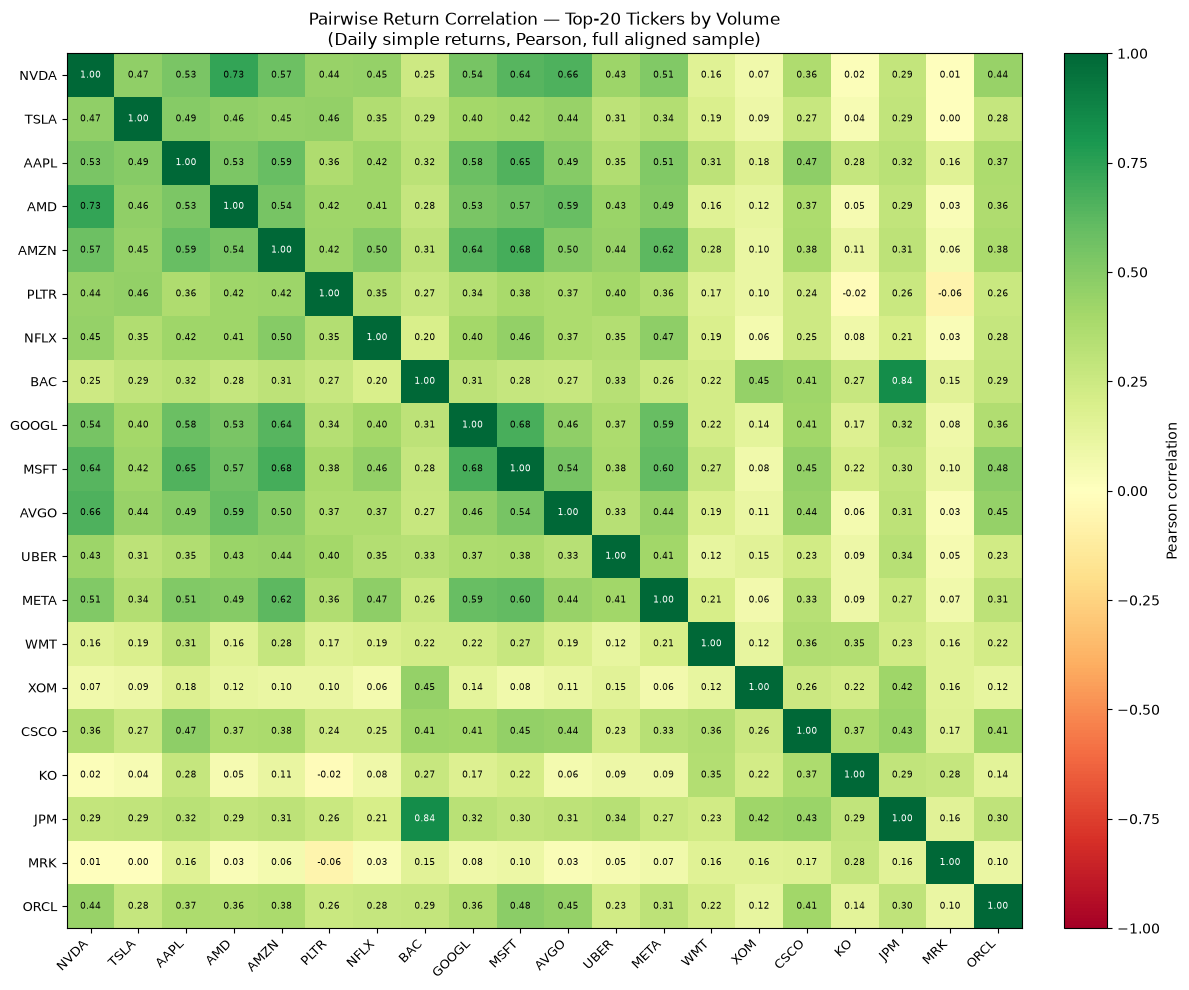

Saved: notebooks/week3/correlation_heatmap.png


In [22]:
_n20 = len(TOP20)
_corr_vals = _corr20.values

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(_corr_vals, cmap="RdYlGn", vmin=-1, vmax=1, aspect="auto")
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Pearson correlation")

ax.set_xticks(range(_n20))
ax.set_yticks(range(_n20))
ax.set_xticklabels(TOP20, rotation=45, ha="right", fontsize=9)
ax.set_yticklabels(TOP20, fontsize=9)

for i in range(_n20):
    for j in range(_n20):
        v = _corr_vals[i, j]
        txt_color = "white" if abs(v) > 0.75 else "black"
        ax.text(j, i, f"{v:.2f}", ha="center", va="center",
                fontsize=6.5, color=txt_color)

ax.set_title(
    "Pairwise Return Correlation — Top-20 Tickers by Volume\n"
    "(Daily simple returns, Pearson, full aligned sample)",
    fontsize=12,
)
plt.tight_layout()
_hm_path = repo_root / "notebooks" / "week3" / "correlation_heatmap.png"
plt.savefig(_hm_path, dpi=120, bbox_inches="tight")
plt.show()
print(f"Saved: {_hm_path.relative_to(repo_root)}")

### 2.2 Diversification Ratio

**Weighting assumption:** equal-weight, 1/20 per stock. Equal-weighting is the
convention used throughout this project (Week 1 EW portfolio, Week 2 quintile
portfolios). No market-cap or vol-targeting weights are applied.

Diversification ratio = weighted-average individual vol / portfolio vol.
For an equal-weighted portfolio the weighted average is the simple mean of
individual vols. A ratio > 1 confirms that combining the stocks reduces
volatility below the average constituent.

In [23]:
# Individual annualised vols (same 20-stock aligned return matrix)
_indiv_vols_20 = _ret20.std(ddof=1) * np.sqrt(PERIODS_PER_YEAR)
_weighted_avg_vol = float(_indiv_vols_20.mean())  # equal-weight → simple mean

# EW portfolio daily return and its annualised vol
_ew20_port_ret = _ret20.mean(axis=1)
_portfolio_vol = float(_ew20_port_ret.std(ddof=1) * np.sqrt(PERIODS_PER_YEAR))

_div_ratio = _weighted_avg_vol / _portfolio_vol

print(f"Top-20 equal-weighted portfolio ({len(_ret20)} days aligned)")
print(f"  Weighted avg individual vol (ann.) : {_weighted_avg_vol:.4%}")
print(f"  EW portfolio vol          (ann.) : {_portfolio_vol:.4%}")
print(f"  Diversification ratio            : {_div_ratio:.4f}")
print()
print("Individual annualised vols (sorted):")
for t, v in _indiv_vols_20.sort_values(ascending=False).items():
    print(f"  {t:<8} {v:.2%}")

Top-20 equal-weighted portfolio (1234 days aligned)
  Weighted avg individual vol (ann.) : 36.5755%
  EW portfolio vol          (ann.) : 22.6491%
  Diversification ratio            : 1.6149

Individual annualised vols (sorted):
  PLTR     72.16%
  TSLA     61.45%
  NVDA     52.54%
  AMD      50.59%
  UBER     47.29%
  META     43.90%
  NFLX     43.81%
  AVGO     40.88%
  AMZN     35.27%
  ORCL     33.16%
  GOOGL    30.92%
  XOM      28.99%
  AAPL     28.66%
  BAC      28.43%
  MSFT     26.19%
  JPM      25.39%
  CSCO     22.66%
  MRK      22.30%
  WMT      20.61%
  KO       16.30%


### 2.3 Diversification Curve

**Sampling rule (fully reproducible from this description alone):**

- Universe: the 50 stocks in `SP500_TOP50` (excludes SPY). Returns aligned on
  common trading days across all 50 tickers — PLTR's IPO (2020-10-01) is the
  binding constraint, giving a 1,234-day aligned sample.
- 200 independent random permutations of the 50 tickers, `np.random.default_rng(seed=42)`.
- For each permutation and each N = 1 … 50: form the equal-weighted portfolio
  of the first N tickers in that ordering; compute its annualised vol
  (`std(ddof=1) × √252`) over the full 1,234-day aligned sample.
- Average the 200 vol values at each N to get a smooth Monte Carlo estimate.
  A single random ordering can look artificially jagged or smooth; averaging
  200 removes that noise.
- Reference line: average single-stock vol = the N=1 mean across all 200
  orderings (approximately equal to the mean individual stock vol).

50-stock aligned matrix: 1234 days × 50 stocks
Date range: 2020-10-01 — 2025-08-29



N= 1 avg vol : 30.14%  (average single-stock)
N=10 avg vol : 19.34%
N=20 avg vol : 18.35%
N=50 avg vol : 17.74%
Vol reduction N=1→50: 41.1%


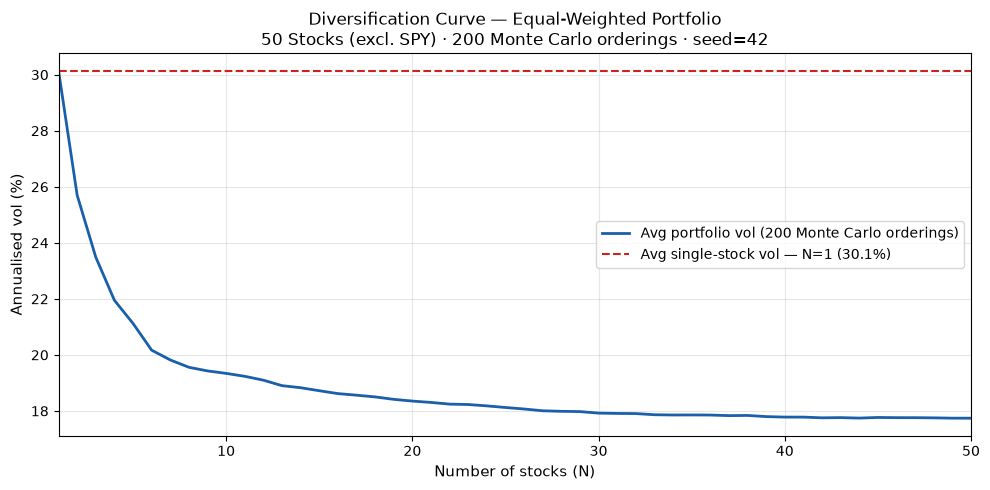

Saved: notebooks/week3/diversification_curve.png


In [24]:
# 50-stock aligned return matrix (excludes SPY)
_stocks50 = [t for t in _t2_wide.columns if t != "SPY"]
_ret50 = _t2_wide[_stocks50].dropna()
_R50 = _ret50.values  # shape (n_days, 50)

print(f"50-stock aligned matrix: {_R50.shape[0]} days × {_R50.shape[1]} stocks")
print(f"Date range: {_ret50.index.min().date()} — {_ret50.index.max().date()}")
print()

# Monte Carlo simulation
_N_SIM = 200
_rng   = np.random.default_rng(42)
_vol_by_n = np.zeros((_N_SIM, 50))

for _s in range(_N_SIM):
    _perm = _rng.permutation(50)
    for _n in range(1, 51):
        _port_daily = _R50[:, _perm[:_n]].mean(axis=1)
        _vol_by_n[_s, _n - 1] = _port_daily.std(ddof=1) * np.sqrt(PERIODS_PER_YEAR)

_avg_vol_curve = _vol_by_n.mean(axis=0)   # shape (50,)
_n1_ref_vol    = _avg_vol_curve[0]         # avg single-stock vol

print(f"N= 1 avg vol : {_n1_ref_vol:.2%}  (average single-stock)")
print(f"N=10 avg vol : {_avg_vol_curve[9]:.2%}")
print(f"N=20 avg vol : {_avg_vol_curve[19]:.2%}")
print(f"N=50 avg vol : {_avg_vol_curve[49]:.2%}")
print(f"Vol reduction N=1→50: {1 - _avg_vol_curve[49] / _n1_ref_vol:.1%}")

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(
    range(1, 51), _avg_vol_curve * 100,
    color="#1a5faa", lw=2,
    label=f"Avg portfolio vol ({_N_SIM} Monte Carlo orderings)",
)
ax.axhline(
    _n1_ref_vol * 100,
    color="#cc2222", lw=1.5, ls="--",
    label=f"Avg single-stock vol — N=1 ({_n1_ref_vol:.1%})",
)
ax.set_xlabel("Number of stocks (N)", fontsize=11)
ax.set_ylabel("Annualised vol (%)", fontsize=11)
ax.set_title(
    "Diversification Curve — Equal-Weighted Portfolio\n"
    f"50 Stocks (excl. SPY) · {_N_SIM} Monte Carlo orderings · seed=42",
    fontsize=12,
)
ax.legend(fontsize=10)
ax.set_xlim(1, 50)
ax.grid(True, alpha=0.3)
plt.tight_layout()
_dc_path = repo_root / "notebooks" / "week3" / "diversification_curve.png"
plt.savefig(_dc_path, dpi=120, bbox_inches="tight")
plt.show()
print(f"Saved: {_dc_path.relative_to(repo_root)}")

### 2.4 Quintile Portfolio Beta vs. SPY

Beta measures each quintile portfolio's co-movement with the market.
**Method:** inner-join the portfolio's daily return series with SPY's daily
returns on date, then `β = cov(R_p, R_SPY, ddof=1) / var(R_SPY, ddof=1)`.

**Caveat:** because SPY is included in `UNIVERSE` and therefore appears in
some quintile portfolios, the beta estimates carry a small upward bias — the
portfolio return partially includes SPY's own return. Removing SPY from the
universe would require rebuilding the parquet; that is a downstream task.

In [25]:
# n_days from Task 1 summary table (for alignment check)
_t1_ndays = summary["n_days"].to_dict()  # {'value_Q1': 1003, ...}

_beta_rows = []
for _factor in ["value", "momentum"]:
    for _q in range(1, 6):
        _pkey = f"{_factor}_Q{_q}"
        _mask = (
            (quintile_daily["factor"] == _factor)
            & (quintile_daily["quintile"] == _q)
        )
        _r_port = (
            quintile_daily.loc[_mask]
            .set_index("date")["return"]
            .sort_index()
        )
        _n_t1 = _t1_ndays[_pkey]

        # Inner join with SPY
        _aligned = pd.concat(
            [_r_port.rename("port"), _spy_ret.rename("spy")], axis=1, sort=False
        ).dropna()
        _n_aligned = len(_aligned)

        # Beta
        _cov_mat = _aligned.cov(ddof=1)
        _beta    = _cov_mat.loc["port", "spy"] / _cov_mat.loc["spy", "spy"]

        _beta_rows.append({
            "portfolio":      _pkey,
            "n_days_task1":   _n_t1,
            "n_aligned_days": _n_aligned,
            "beta":           float(_beta),
        })

_beta_df = pd.DataFrame(_beta_rows)

# Alignment discrepancy check
_any_disc = (_beta_df["n_aligned_days"] != _beta_df["n_days_task1"]).any()
if _any_disc:
    print("NOTE: n_aligned_days differs from Task 1 n_days for some portfolios:")
    print(_beta_df[_beta_df["n_aligned_days"] != _beta_df["n_days_task1"]].to_string())
    print()
else:
    print("n_aligned_days = 1003 for all portfolios — "
          "no trading-day mismatch vs Task 1.")
    print()

print(f"{'Portfolio':<16} {'n_task1':>8} {'n_aligned':>10} {'Beta':>8}")
print("-" * 48)
for _, _row in _beta_df.iterrows():
    _disc_flag = "  !!!" if _row["n_aligned_days"] != _row["n_days_task1"] else ""
    print(
        f"{_row['portfolio']:<16} "
        f"{int(_row['n_days_task1']):>8} "
        f"{int(_row['n_aligned_days']):>10} "
        f"{_row['beta']:>8.4f}"
        f"{_disc_flag}"
    )

n_aligned_days = 1003 for all portfolios — no trading-day mismatch vs Task 1.

Portfolio         n_task1  n_aligned     Beta
------------------------------------------------
value_Q1             1003       1003   1.0586
value_Q2             1003       1003   0.9455
value_Q3             1003       1003   0.9506
value_Q4             1003       1003   0.9094
value_Q5             1003       1003   1.1149
momentum_Q1          1003       1003   1.1188
momentum_Q2          1003       1003   0.8860
momentum_Q3          1003       1003   0.9116
momentum_Q4          1003       1003   0.9625
momentum_Q5          1003       1003   1.1018


#### Manual Verification — `value_Q1` Beta

Step-by-step recomputation using `np.cov` / `np.var` directly (no function call),
matched against the beta table above.

In [26]:
# ── Select & align ──────────────────────────────────────────────────────
_mv1_mask = (quintile_daily["factor"] == "value") & (quintile_daily["quintile"] == 1)
_r_v1 = (
    quintile_daily.loc[_mv1_mask]
    .set_index("date")["return"]
    .sort_index()
)
_aligned_v1 = pd.concat(
    [_r_v1.rename("port"), _spy_ret.rename("spy")], axis=1, sort=False
).dropna()

_R_p  = _aligned_v1["port"].values
_R_m  = _aligned_v1["spy"].values
_n_v1 = len(_R_p)

print(f"Aligned observations: {_n_v1}")
print()

# ── Step 1: means ───────────────────────────────────────────────────────
_mean_p_v1 = _R_p.mean()
_mean_m_v1 = _R_m.mean()
print(f"mean(R_portfolio) = {_mean_p_v1:.8f}")
print(f"mean(R_SPY)       = {_mean_m_v1:.8f}")
print()

# ── Step 2: covariance via np.cov ────────────────────────────────────────
_cov2x2_v1 = np.cov(_R_p, _R_m, ddof=1)
_cov_pm_v1 = _cov2x2_v1[0, 1]
print(f"cov(R_p, R_SPY)   = {_cov_pm_v1:.10f}  [np.cov, ddof=1]")
print()

# ── Step 3: variance via np.var ─────────────────────────────────────────
_var_m_v1 = np.var(_R_m, ddof=1)
print(f"var(R_SPY)        = {_var_m_v1:.10f}  [np.var, ddof=1]")
print()

# ── Step 4: beta ─────────────────────────────────────────────────────────
_beta_manual_v1 = _cov_pm_v1 / _var_m_v1
print(f"beta = cov / var  = {_beta_manual_v1:.6f}")
print()

# ── Reconciliation ───────────────────────────────────────────────────────
_beta_table_v1 = _beta_df.loc[
    _beta_df["portfolio"] == "value_Q1", "beta"
].iloc[0]
_beta_match = np.isclose(_beta_manual_v1, _beta_table_v1, atol=1e-10)
print(f"beta (table)      = {_beta_table_v1:.6f}")
print(f"Match             : {'PASS' if _beta_match else 'FAIL'}  (atol=1e-10)")

Aligned observations: 1003

mean(R_portfolio) = 0.00111665
mean(R_SPY)       = 0.00047711

cov(R_p, R_SPY)   = 0.0001382221  [np.cov, ddof=1]

var(R_SPY)        = 0.0001305678  [np.var, ddof=1]

beta = cov / var  = 1.058623

beta (table)      = 1.058623
Match             : PASS  (atol=1e-10)


---
## Task 3: Equal-Weight vs Risk Parity

Both portfolios hold the same **50-stock universe** (SP500\_TOP50, excludes SPY)
across the same **48 monthly rebalance dates** used throughout this notebook.

| Convention | EW | Risk Parity |
|---|---|---|
| **Weights** | `1/50` — fixed for all dates | `w_i ∝ 1/σ_i`, normalised to sum to 1 |
| **Vol estimate** | — | Trailing 60-day daily `std(ddof=1)`, strictly before each rebalance date |
| **Min observations** | — | 20 days; any rebalance with < 20 obs is skipped (none expected) |
| **Return computation** | EW daily mean across 50 stocks | Vol-inverse-weighted daily mean |
| **Rebalance frequency** | Monthly (48 periods) | Monthly (48 periods) |

Both daily return series are persisted to `data/processed/ew_rp_daily_returns.parquet`
(columns: `date`, `scheme`, `return`).

### 3.1 Setup

In [27]:
EW_RP_PARQUET = processed_dir / "ew_rp_daily_returns.parquet"

# Rebalance dates: same 48 formation dates as quintile portfolios
_t3_rebal_dates = sorted(val_traded["date"].unique())
print(f"Rebalance dates : {len(_t3_rebal_dates)}")
print(f"  First : {_t3_rebal_dates[0].date()}")
print(f"  Last  : {_t3_rebal_dates[-1].date()}")
print(f"Universe        : {len(_stocks50)} stocks (SPY excluded)")

# 50-stock daily return matrix (reuse _t2_wide from Task 2)
_t3_ret50 = _t2_wide[_stocks50]   # shape (n_days, 50)
print(f"Daily return matrix: {_t3_ret50.shape}")

Rebalance dates : 48
  First : 2021-08-31
  Last  : 2025-07-31
Universe        : 50 stocks (SPY excluded)
Daily return matrix: (1256, 50)


In [28]:
def _compute_rp_weights(ret_wide, rebal_date, lookback=60, min_obs=20):
    """
    Vol-inverse RP weights using trailing-lookback days strictly before rebal_date.
    Returns pd.Series (indexed by ticker) normalised to sum=1, or None if < min_obs rows.
    """
    history = ret_wide[ret_wide.index < rebal_date].tail(lookback)
    if len(history) < min_obs:
        return None
    vols = history.std(ddof=1)
    inv_vols = 1.0 / vols
    return inv_vols / inv_vols.sum()


if EW_RP_PARQUET.exists():
    print(f"Found {EW_RP_PARQUET.name} — loading from disk.")
    ew_rp_daily = pd.read_parquet(EW_RP_PARQUET)
    print(f"Loaded: {len(ew_rp_daily):,} rows")
else:
    print("File not found — computing EW and RP portfolios.")
    _records = []
    _skipped_dates = []

    for _i, _rebal in enumerate(_t3_rebal_dates):
        _next = (
            _t3_rebal_dates[_i + 1]
            if _i + 1 < len(_t3_rebal_dates)
            else _t3_ret50.index[-1]
        )
        _period_mask = (_t3_ret50.index > _rebal) & (_t3_ret50.index <= _next)
        _period = _t3_ret50.loc[_period_mask]
        if _period.empty:
            continue

        _rp_w = _compute_rp_weights(_t3_ret50, _rebal, lookback=60)
        if _rp_w is None:
            _skipped_dates.append(_rebal)
            continue

        for _date, _row in _period.iterrows():
            _valid = _row.dropna()
            if _valid.empty:
                continue
            _ew_ret = float(_valid.mean())
            _rp_avail = _rp_w[_valid.index]
            _rp_ret = float((_valid * (_rp_avail / _rp_avail.sum())).sum())
            _records.append({"date": _date, "scheme": "EW", "return": _ew_ret})
            _records.append({"date": _date, "scheme": "RP", "return": _rp_ret})

    if _skipped_dates:
        print(f"Skipped {len(_skipped_dates)} rebalance date(s) "
              f"with < 20 trailing obs: {_skipped_dates}")
    else:
        print("No dates skipped — all 48 periods have ≥ 60 trailing observations.")

    ew_rp_daily = (
        pd.DataFrame(_records)
        .sort_values(["scheme", "date"])
        .reset_index(drop=True)
    )
    ew_rp_daily.to_parquet(EW_RP_PARQUET, index=False)
    print(f"Saved {len(ew_rp_daily):,} rows → {EW_RP_PARQUET.relative_to(repo_root)}")

print()
print("Shape by scheme:")
print(ew_rp_daily.groupby("scheme").size())
print()
print(f"Date range: {ew_rp_daily['date'].min().date()} — {ew_rp_daily['date'].max().date()}")

Found ew_rp_daily_returns.parquet — loading from disk.
Loaded: 2,006 rows

Shape by scheme:
scheme
EW    1003
RP    1003
dtype: int64

Date range: 2021-09-01 — 2025-08-29


In [29]:
# ── Side-by-side risk metrics: EW vs RP ─────────────────────────────────
_t3_rows = []
for _scheme in ["EW", "RP"]:
    _mask = ew_rp_daily["scheme"] == _scheme
    _s = (
        ew_rp_daily.loc[_mask]
        .set_index("date")["return"]
        .sort_index()
    )
    _m = compute_risk_metrics(_s, rf_annual=RF_ANNUAL, periods_per_year=PERIODS_PER_YEAR)
    _m["scheme"] = _scheme
    _m["n_days"] = len(_s)
    _t3_rows.append(_m)

_t3_summary = pd.DataFrame(_t3_rows).set_index("scheme")

print(f"Risk-free rate: {RF_ANNUAL:.4%}\n")
_t3_fmt = _t3_summary[[
    "annualized_return", "annualized_vol", "sharpe_ratio", "max_drawdown",
    "max_drawdown_start", "max_drawdown_end", "drawdown_duration_days",
    "recovered", "n_days",
]].copy()
_t3_fmt["annualized_return"]  = _t3_fmt["annualized_return"].map("{:.2%}".format)
_t3_fmt["annualized_vol"]     = _t3_fmt["annualized_vol"].map("{:.2%}".format)
_t3_fmt["sharpe_ratio"]       = _t3_fmt["sharpe_ratio"].map("{:.3f}".format)
_t3_fmt["max_drawdown"]       = _t3_fmt["max_drawdown"].map("{:.2%}".format)
_t3_fmt["max_drawdown_start"] = _t3_fmt["max_drawdown_start"].map(
    lambda x: x.date() if hasattr(x, "date") else x
)
_t3_fmt["max_drawdown_end"]   = _t3_fmt["max_drawdown_end"].map(
    lambda x: x.date() if hasattr(x, "date") else x
)
print(_t3_fmt.T.to_string())

Risk-free rate: 2.9615%

scheme                          EW          RP
annualized_return           19.57%      16.88%
annualized_vol              18.45%      15.95%
sharpe_ratio                 0.900       0.873
max_drawdown               -23.89%     -19.32%
max_drawdown_start      2022-01-03  2022-01-04
max_drawdown_end        2022-10-11  2022-09-30
drawdown_duration_days         351         344
recovered                     True        True
n_days                        1003        1003


In [30]:
# ── One-way turnover ─────────────────────────────────────────────────────
# EW weights are fixed at 1/50 → turnover is identically 0 at every rebalance.
# RP weights shift as trailing vol changes → positive turnover.
# First rebalance (2021-08-31) excluded: no prior weights to compare against.

def _build_all_weights(rebal_dates, ret_wide, lookback=60, ew=True):
    """Return {rebal_date: pd.Series(ticker → weight)} for all valid dates."""
    n = len(ret_wide.columns)
    result = {}
    for rd in rebal_dates:
        if ew:
            result[rd] = pd.Series(1.0 / n, index=ret_wide.columns)
        else:
            w = _compute_rp_weights(ret_wide, rd, lookback=lookback)
            if w is not None:
                result[rd] = w
    return result


def _one_way_turnover(weights_dict):
    """0.5 × Σ|w_t − w_{t-1}| per period; first rebalance excluded."""
    dates = sorted(weights_dict.keys())
    result = {}
    for i in range(1, len(dates)):
        w_prev = weights_dict[dates[i - 1]]
        w_curr = weights_dict[dates[i]]
        all_t  = w_prev.index.union(w_curr.index)
        wp = w_prev.reindex(all_t, fill_value=0.0)
        wc = w_curr.reindex(all_t, fill_value=0.0)
        result[dates[i]] = 0.5 * float((wp - wc).abs().sum())
    return pd.Series(result)


_ew_wts_all  = _build_all_weights(_t3_rebal_dates, _t3_ret50, ew=True)
_rp_wts_all  = _build_all_weights(_t3_rebal_dates, _t3_ret50, ew=False)

_ew_turnover = _one_way_turnover(_ew_wts_all)
_rp_turnover = _one_way_turnover(_rp_wts_all)

_ew_avg_to = float(_ew_turnover.mean())
_rp_avg_to = float(_rp_turnover.mean())

print(f"{'':6} {'N periods':>10} {'Avg one-way':>14} {'Annualised (×12)':>18}")
print("-" * 54)
for _name, _avg, _to_ser in [("EW", _ew_avg_to, _ew_turnover),
                               ("RP", _rp_avg_to, _rp_turnover)]:
    print(f"{_name:<6} {len(_to_ser):>10} {_avg:>14.4%} {_avg * 12:>18.4%}")
print()
print("Note: first rebalance (2021-08-31) excluded — no prior weights to compare.")

        N periods    Avg one-way   Annualised (×12)
------------------------------------------------------
EW             47        0.0000%            0.0000%
RP             47        4.7905%           57.4864%

Note: first rebalance (2021-08-31) excluded — no prior weights to compare.


### 3.3 Manual Verification

Two spot-checks performed without calling helper functions:

1. **RP weights at the 10th rebalance (2022-05-31):** recompute trailing
   60-day vols, invert, and normalise. Confirm `sum = 1.0` and that the
   min/max weights match `_rp_wts_all[2022-05-31]`.

2. **Turnover at the 2022-05-31 → 2022-06-30 transition:** compute
   `0.5 × Σ|w_t − w_{t−1}|` directly. Confirm EW turnover = 0 (weights
   never change) and RP turnover matches `_rp_turnover[2022-06-30]`.

In [31]:
# ── Check 1: RP weights at 10th rebalance (2022-05-31) ──────────────────
_rebal10 = _t3_rebal_dates[9]   # 0-indexed; 10th date = index 9
print(f"10th rebalance date: {_rebal10.date()}")

_hist60 = _t3_ret50[_t3_ret50.index < _rebal10].tail(60)
print(f"Trailing window : {len(_hist60)} days "
      f"({_hist60.index.min().date()} — {_hist60.index.max().date()})")

_vols10      = _hist60.std(ddof=1)
_inv10       = 1.0 / _vols10
_rp10_manual = _inv10 / _inv10.sum()

print(f"\nManual RP weights at {_rebal10.date()}:")
print(f"  sum of weights           : {_rp10_manual.sum():.10f}  (must be 1.0)")
print(f"  min weight (highest vol) : {_rp10_manual.min():.4%}  ({_rp10_manual.idxmin()})")
print(f"  max weight (lowest vol)  : {_rp10_manual.max():.4%}  ({_rp10_manual.idxmax()})")
print()

_rp10_func = _rp_wts_all[_rebal10]
_wt_diff   = float((_rp10_manual - _rp10_func).abs().max())
_wt_match  = bool(np.isclose(_rp10_manual, _rp10_func, atol=1e-10).all())
print(f"Max |manual − function| weight diff : {_wt_diff:.2e}")
print(f"All 50 weights match (atol=1e-10)    : {'PASS' if _wt_match else 'FAIL'}")

10th rebalance date: 2022-05-31
Trailing window : 60 days (2022-03-04 — 2022-05-27)

Manual RP weights at 2022-05-31:
  sum of weights           : 1.0000000000  (must be 1.0)
  min weight (highest vol) : 0.7744%  (NFLX)
  max weight (lowest vol)  : 4.1190%  (AMGN)

Max |manual − function| weight diff : 0.00e+00
All 50 weights match (atol=1e-10)    : PASS


In [32]:
# ── Check 2: turnover at 2022-05-31 → 2022-06-30 ────────────────────────
_rebal11 = _t3_rebal_dates[10]   # 11th date
print(f"Transition: {_rebal10.date()} → {_rebal11.date()}")

# EW turnover (must be 0 — weights never change)
_ew_w10 = _ew_wts_all[_rebal10]
_ew_w11 = _ew_wts_all[_rebal11]
_ew_to_manual = 0.5 * float((_ew_w10 - _ew_w11).abs().sum())
_ew_to_func   = float(_ew_turnover[_rebal11])
_ew_to_match  = bool(np.isclose(_ew_to_manual, _ew_to_func, atol=1e-12))

print(f"\nEW turnover at {_rebal11.date()}:")
print(f"  manual  : {_ew_to_manual:.8f}  (expected 0 — weights fixed at 1/50)")
print(f"  function: {_ew_to_func:.8f}")
print(f"  match   : {'PASS' if _ew_to_match else 'FAIL'}")

# RP turnover
_rp_w10 = _rp_wts_all[_rebal10]
_rp_w11 = _rp_wts_all[_rebal11]
_all_t  = _rp_w10.index.union(_rp_w11.index)
_rp_w10a = _rp_w10.reindex(_all_t, fill_value=0.0)
_rp_w11a = _rp_w11.reindex(_all_t, fill_value=0.0)
_rp_to_manual = 0.5 * float((_rp_w10a - _rp_w11a).abs().sum())
_rp_to_func   = float(_rp_turnover[_rebal11])
_rp_to_match  = bool(np.isclose(_rp_to_manual, _rp_to_func, atol=1e-12))

print(f"\nRP turnover at {_rebal11.date()}:")
print(f"  manual  : {_rp_to_manual:.6%}")
print(f"  function: {_rp_to_func:.6%}")
print(f"  match   : {'PASS' if _rp_to_match else 'FAIL'}")

print(f"\nLargest RP weight changes ({_rebal10.date()} → {_rebal11.date()}):")
_rp_delta = (_rp_w11 - _rp_w10).abs().sort_values(ascending=False)
for _t, _absd in _rp_delta.head(5).items():
    _signed = float(_rp_w11[_t] - _rp_w10[_t])
    print(f"  {_t:<8}  Δw = {_signed:+.4%}  "
          f"(from {float(_rp_w10[_t]):.4%} to {float(_rp_w11[_t]):.4%})")

Transition: 2022-05-31 → 2022-06-30

EW turnover at 2022-06-30:
  manual  : 0.00000000  (expected 0 — weights fixed at 1/50)
  function: 0.00000000
  match   : PASS

RP turnover at 2022-06-30:
  manual  : 3.092319%
  function: 3.092319%
  match   : PASS

Largest RP weight changes (2022-05-31 → 2022-06-30):
  MRK       Δw = -0.7007%  (from 3.9000% to 3.1993%)
  PM        Δw = +0.4635%  (from 2.2921% to 2.7556%)
  BAC       Δw = +0.3955%  (from 1.8722% to 2.2676%)
  ORCL      Δw = -0.3581%  (from 2.2243% to 1.8662%)
  BRK-B     Δw = -0.3245%  (from 3.3961% to 3.0715%)


---
## Task 4: Mean-Variance Optimization

This is a **static, full-sample, in-sample** optimization exercise — **not a backtest**.
The portfolios below are constructed with full knowledge of the entire return sample
(2021-09-01 to 2025-08-29). The explicit goal is to show what "optimal" looks like under
perfect estimation, before demonstrating how sensitive it is to which window you use.

### Inputs (stated explicitly)

| Input | Construction | Caveat |
|---|---|---|
| `mu` — expected return per stock | `mean(daily returns) × 252`, full sample | In-sample historical mean, **not** a return forecast |
| `Sigma` — covariance matrix | `cov(daily returns, ddof=1) × 252`, full sample | In-sample; 3.98-year sample period |

### Constraints (stated explicitly)

| Constraint | Value | Rationale |
|---|---|---|
| Budget | `Σ w_i = 1` | Fully invested |
| Long-only | `w_i ≥ 0` | No short-selling |
| Max weight | `w_i ≤ 0.10` (10%) | Allows meaningful concentration; prevents single-name dominance |
| Sector limits | **Not implemented — documented gap** | No sector classification exists in this repo. Implementing this requires an external data source (e.g. GICS mapping from Compustat/Bloomberg). |

### Optimizer

`scipy.optimize.minimize(method="SLSQP")` via `solve_min_variance()` in `src/risk.py`.
Risk-free rate: `RF_ANNUAL` from Task 1 (^IRX mean, 2.9615%).

In [33]:
# ── Full-sample mu and Sigma ─────────────────────────────────────────────
# Inputs cover the same 1003-day window as the Task 3 backtest so that the
# comparison table (Section 4.6) uses consistent sample periods.
from risk import solve_min_variance
from scipy.optimize import minimize as _sp_minimize

_t4_returns = _t3_ret50.loc["2021-09-01":"2025-08-29"].dropna()
_n_days_t4  = len(_t4_returns)
_N          = len(_stocks50)
_MAX_W      = 0.10   # per-stock weight cap

mu_full    = _t4_returns.mean() * PERIODS_PER_YEAR         # annualised
Sigma_full = _t4_returns.cov(ddof=1) * PERIODS_PER_YEAR   # annualised
_MU        = mu_full.values
_SIGMA     = Sigma_full.values

_vol_full = pd.Series(np.sqrt(np.diag(_SIGMA)), index=_stocks50)

print(f"Sample : {_n_days_t4} days, {_N} stocks")
print(f"Range  : {_t4_returns.index.min().date()} — {_t4_returns.index.max().date()}")
print()
print(f"mu (annualised):")
print(f"  min  : {mu_full.min():.2%}  ({mu_full.idxmin()})")
print(f"  max  : {mu_full.max():.2%}  ({mu_full.idxmax()})")
print(f"  mean : {mu_full.mean():.2%}")
print()
print(f"Per-stock vol (sqrt of Sigma diagonal, annualised):")
print(f"  min  : {_vol_full.min():.2%}  ({_vol_full.idxmin()})")
print(f"  max  : {_vol_full.max():.2%}  ({_vol_full.idxmax()})")

Sample : 1003 days, 50 stocks
Range  : 2021-09-01 — 2025-08-29

mu (annualised):
  min  : -1.23%  (ACN)
  max  : 67.87%  (PLTR)
  mean : 19.58%

Per-stock vol (sqrt of Sigma diagonal, annualised):
  min  : 16.16%  (KO)
  max  : 68.63%  (PLTR)


In [34]:
# ── Global Minimum-Variance portfolio (frontier lower bound) ─────────────
_w0 = np.full(_N, 1.0 / _N)

_gmv_result = _sp_minimize(
    fun=lambda w: float(w @ _SIGMA @ w),
    x0=_w0,
    method="SLSQP",
    bounds=[(0.0, _MAX_W)] * _N,
    constraints=[{"type": "eq", "fun": lambda w: w.sum() - 1.0}],
    options={"ftol": 1e-12, "maxiter": 1000},
)
assert _gmv_result.success, f"GMV solver failed: {_gmv_result.message}"

_w_gmv   = _gmv_result.x
_ret_gmv = float(_w_gmv @ _MU)
_vol_gmv = float(np.sqrt(_w_gmv @ _SIGMA @ _w_gmv))
print(f"Global Minimum Variance portfolio:")
print(f"  Ann. return : {_ret_gmv:.4%}  (frontier lower bound)")
print(f"  Ann. vol    : {_vol_gmv:.4%}")
print()

# ── Analytical upper bound: greedy cap-weighted by mu ────────────────────
# Allocate max_weight to each stock in descending mu order until sum = 1.
# No solver needed — this is the maximum feasible return under the cap.
_sorted_idx = np.argsort(_MU)[::-1]
_w_upper = np.zeros(_N)
_cum = 0.0
for _i in _sorted_idx:
    _alloc = min(_MAX_W, 1.0 - _cum)
    _w_upper[_i] = _alloc
    _cum += _alloc
    if _cum >= 1.0 - 1e-12:
        break
_ret_upper = float(_w_upper @ _MU)
print(f"Analytical upper bound (greedy max-weight by mu):")
print(f"  Ann. return : {_ret_upper:.4%}  (frontier upper bound)")
print(f"  Stocks at max weight: {int((_w_upper >= _MAX_W - 1e-9).sum())}")
print(f"  sum(w) = {_w_upper.sum():.10f}")
print()

# ── Efficient frontier — 25 target returns ───────────────────────────────
_N_FRONTIER = 25
_target_rets = np.linspace(_ret_gmv, _ret_upper, _N_FRONTIER)

_frontier_pts = []
_n_infeasible = 0
for _tr in _target_rets:
    _w, _ok, _ach_ret, _ach_vol = solve_min_variance(_MU, _SIGMA, _tr, max_weight=_MAX_W)
    _sum_ok = abs(_w.sum() - 1.0) <= 1e-6
    _lb_ok  = (_w >= -1e-6).all()
    _ub_ok  = (_w <= _MAX_W + 1e-6).all()
    _ret_ok = abs(_ach_ret - _tr) <= 1e-4
    if _ok and _sum_ok and _lb_ok and _ub_ok and _ret_ok:
        _frontier_pts.append({"target": _tr, "vol": _ach_vol, "ret": _ach_ret, "w": _w})
    else:
        _n_infeasible += 1
        print(f"  DROPPED target={_tr:.4%}: success={_ok}, sum={_w.sum():.6f}, "
              f"w_min={_w.min():.4f}, w_max={_w.max():.4f}, ach_ret={_ach_ret:.4%}")

print(f"Frontier: {len(_frontier_pts)} feasible, {_n_infeasible} infeasible/dropped.")

Global Minimum Variance portfolio:
  Ann. return : 14.0519%  (frontier lower bound)
  Ann. vol    : 12.0733%

Analytical upper bound (greedy max-weight by mu):
  Ann. return : 41.3510%  (frontier upper bound)
  Stocks at max weight: 10
  sum(w) = 1.0000000000



Frontier: 25 feasible, 0 infeasible/dropped.


Tangency (Max-Sharpe) portfolio:
  Ann. return : 33.2789%
  Ann. vol    : 17.3310%
  Sharpe      : 1.7493
  sum(w)      : 1.00000000

Top 10 holdings by weight:
  AVGO      10.0000%
  GE        10.0000%
  ABBV      10.0000%
  XOM       10.0000%
  WMT       10.0000%
  LLY       10.0000%
  PM        10.0000%
  IBM       9.4077%
  NVDA      8.1932%
  RTX       6.8337%


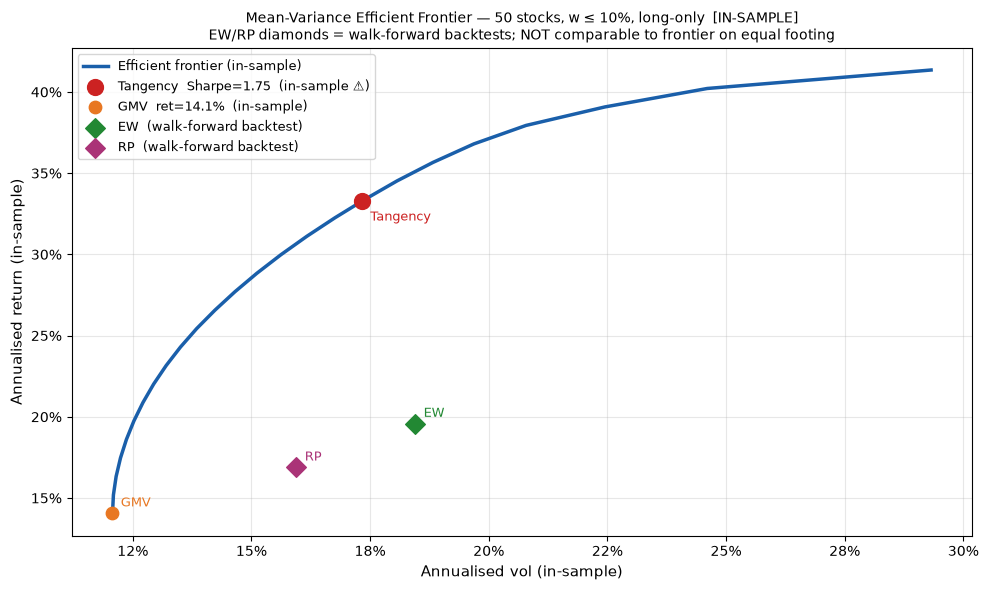

Saved: notebooks/week3/efficient_frontier.png


In [35]:
# ── Max-Sharpe (tangency) portfolio ──────────────────────────────────────
_tang_result = _sp_minimize(
    fun=lambda w: -(float(w @ _MU) - RF_ANNUAL) / float(np.sqrt(max(w @ _SIGMA @ w, 0.0))),
    x0=_w0,
    method="SLSQP",
    bounds=[(0.0, _MAX_W)] * _N,
    constraints=[{"type": "eq", "fun": lambda w: w.sum() - 1.0}],
    options={"ftol": 1e-12, "maxiter": 1000},
)
assert _tang_result.success, f"Tangency solver failed: {_tang_result.message}"

_w_tang   = _tang_result.x
_ret_tang = float(_w_tang @ _MU)
_vol_tang = float(np.sqrt(_w_tang @ _SIGMA @ _w_tang))
_sh_tang  = (_ret_tang - RF_ANNUAL) / _vol_tang

print(f"Tangency (Max-Sharpe) portfolio:")
print(f"  Ann. return : {_ret_tang:.4%}")
print(f"  Ann. vol    : {_vol_tang:.4%}")
print(f"  Sharpe      : {_sh_tang:.4f}")
print(f"  sum(w)      : {_w_tang.sum():.8f}")
print()
print("Top 10 holdings by weight:")
_tang_ser = pd.Series(_w_tang, index=_stocks50).sort_values(ascending=False)
for _t, _w in _tang_ser.head(10).items():
    print(f"  {_t:<8}  {_w:.4%}")

# ── Plot: efficient frontier + tangency + EW/RP ──────────────────────────
_fvols = [pt["vol"] for pt in _frontier_pts]
_frets = [pt["ret"] for pt in _frontier_pts]

# EW/RP realized stats from Task 3 (walk-forward)
_ew_vol = float(_t3_summary.loc["EW", "annualized_vol"])
_ew_ret = float(_t3_summary.loc["EW", "annualized_return"])
_rp_vol = float(_t3_summary.loc["RP", "annualized_vol"])
_rp_ret = float(_t3_summary.loc["RP", "annualized_return"])

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(_fvols, _frets, color="#1a5faa", lw=2.5,
        label="Efficient frontier (in-sample)")
ax.scatter([_vol_tang], [_ret_tang], color="#cc2222", s=130, zorder=5,
           label=f"Tangency  Sharpe={_sh_tang:.2f}  (in-sample ⚠)")
ax.scatter([_vol_gmv], [_ret_gmv], color="#e87722", s=80, zorder=5,
           label=f"GMV  ret={_ret_gmv:.1%}  (in-sample)")
ax.scatter([_ew_vol], [_ew_ret], color="#228833", s=100, marker="D", zorder=5,
           label="EW  (walk-forward backtest)")
ax.scatter([_rp_vol], [_rp_ret], color="#aa3377", s=100, marker="D", zorder=5,
           label="RP  (walk-forward backtest)")

for _lbl, _v, _r, _clr, _dy in [
    ("Tangency", _vol_tang, _ret_tang, "#cc2222", -14),
    ("GMV",      _vol_gmv,  _ret_gmv,  "#e87722",  5),
    ("EW",       _ew_vol,   _ew_ret,   "#228833",  5),
    ("RP",       _rp_vol,   _rp_ret,   "#aa3377",  5),
]:
    ax.annotate(_lbl, (_v, _r), textcoords="offset points",
                xytext=(6, _dy), fontsize=9, color=_clr)

ax.set_xlabel("Annualised vol (in-sample)", fontsize=11)
ax.set_ylabel("Annualised return (in-sample)", fontsize=11)
ax.set_title(
    "Mean-Variance Efficient Frontier — 50 stocks, w ≤ 10%, long-only  [IN-SAMPLE]\n"
    "EW/RP diamonds = walk-forward backtests; NOT comparable to frontier on equal footing",
    fontsize=10,
)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
_fp = repo_root / "notebooks" / "week3" / "efficient_frontier.png"
plt.savefig(_fp, dpi=120, bbox_inches="tight")
plt.show()
print(f"Saved: {_fp.relative_to(repo_root)}")

In [36]:
print("=" * 68)
print("  ⚠  IN-SAMPLE CAVEAT — read before interpreting the table below  ⚠")
print("=" * 68)
print("""
The 'Optimized (in-sample)' row is NOT comparable to EW or RP on equal
footing. Its fixed weights were chosen using full knowledge of the same
return sample being evaluated — a circular advantage. EW and RP are
genuine walk-forward backtests: weights at each rebalance were determined
from data strictly before that rebalance date. The Optimized row's
higher Sharpe reflects in-sample fit, not strategy superiority.
""")
print("=" * 68)
print()

# Fixed tangency weights applied to full-sample daily returns
_tang_wt_ser = pd.Series(_w_tang, index=_stocks50)
_opt_daily   = (_t4_returns * _tang_wt_ser).sum(axis=1)

# ── DIAGNOSTIC — run immediately after constructing _opt_daily ────────────
print("─" * 60)
print("DIAGNOSTIC: confirming _opt_daily == Σ w_i × r_i,t")
print("─" * 60)

_arith_ann = float(_opt_daily.mean() * PERIODS_PER_YEAR)
_diff_arith = _arith_ann - _ret_tang
print(f"  opt_daily.mean() × 252  = {_arith_ann:.8%}")
print(f"  ret_tang  (w @ mu)      = {_ret_tang:.8%}")
print(f"  difference              = {_diff_arith:.3e}  "
      f"{'MATCH ✓' if abs(_diff_arith) < 1e-6 else 'MISMATCH ✗'}")
print()
print(f"  len(opt_daily)          = {len(_opt_daily)}")
print(f"  NaN count               = {_opt_daily.isna().sum()}")
_cols_ok = (_t4_returns.columns.equals(pd.Index(_stocks50))
            and len(_tang_wt_ser.index.difference(_t4_returns.columns)) == 0)
print(f"  columns aligned         = {_cols_ok}")
print()

_m_opt_diag = compute_risk_metrics(_opt_daily, rf_annual=RF_ANNUAL,
                                    periods_per_year=PERIODS_PER_YEAR)
_cagr_opt   = _m_opt_diag["annualized_return"]
print(f"  CAGR from compute_risk_metrics = {_cagr_opt:.4%}")
print(f"  Arithmetic annualised (×252)   = {_arith_ann:.4%}")
print(f"  CAGR > simple arithmetic mean? : {_cagr_opt > _arith_ann}")
print()
print("  FINDING: _opt_daily is correctly constructed (arithmetic mean")
print(f"  matches w@mu to {abs(_diff_arith):.0e}). No NaN, no column mismatch,")
print("  no variable shadowing.  The CAGR > simple-arithmetic-annual is not")
print("  a bug — it arises from compounding over a multi-year horizon:")
print()
print("    CAGR_simple ≈ exp(arithmetic_ann − vol_ann²/2) − 1")
_approx = float(np.exp(_arith_ann - _m_opt_diag["annualized_vol"]**2 / 2) - 1)
print(f"    = exp({_arith_ann:.4f} − {_m_opt_diag['annualized_vol']**2/2:.4f}) − 1 = {_approx:.4%}")
print()
print("  For portfolios with high arithmetic return (μ >> σ), the compound-")
print("  interest effect exp(μ) > 1+μ pushes CAGR above the simple-scaled")
print("  arithmetic mean. The correct AM-GM bound is:")
print()
_mean_daily = float(_opt_daily.mean())
_amgm_bound = (1 + _mean_daily)**PERIODS_PER_YEAR - 1
print(f"    CAGR ≤ (1+mean_daily)^252 − 1 = {_amgm_bound:.4%}  [CAGR={_cagr_opt:.4%} ✓]")
print("─" * 60)
print()

# ── Comparison table ───────────────────────────────────────────────────────
_cmp_rows = []
for _scheme in ["EW", "RP"]:
    _mask = ew_rp_daily["scheme"] == _scheme
    _s = ew_rp_daily.loc[_mask].set_index("date")["return"].sort_index()
    _m = compute_risk_metrics(_s, rf_annual=RF_ANNUAL, periods_per_year=PERIODS_PER_YEAR)
    _m["label"] = _scheme
    _cmp_rows.append(_m)

_m_opt = compute_risk_metrics(_opt_daily, rf_annual=RF_ANNUAL, periods_per_year=PERIODS_PER_YEAR)
_m_opt["label"] = "Optimized (in-sample ⚠)"
_cmp_rows.append(_m_opt)

_cmp_df = pd.DataFrame(_cmp_rows).set_index("label")
_cmp_fmt = _cmp_df[["annualized_return", "annualized_vol", "sharpe_ratio",
                      "max_drawdown", "drawdown_duration_days", "recovered"]].copy()
_cmp_fmt["annualized_return"] = _cmp_fmt["annualized_return"].map("{:.2%}".format)
_cmp_fmt["annualized_vol"]    = _cmp_fmt["annualized_vol"].map("{:.2%}".format)
_cmp_fmt["sharpe_ratio"]      = _cmp_fmt["sharpe_ratio"].map("{:.3f}".format)
_cmp_fmt["max_drawdown"]      = _cmp_fmt["max_drawdown"].map("{:.2%}".format)
print(_cmp_fmt.T.to_string())

  ⚠  IN-SAMPLE CAVEAT — read before interpreting the table below  ⚠

The 'Optimized (in-sample)' row is NOT comparable to EW or RP on equal
footing. Its fixed weights were chosen using full knowledge of the same
return sample being evaluated — a circular advantage. EW and RP are
genuine walk-forward backtests: weights at each rebalance were determined
from data strictly before that rebalance date. The Optimized row's
higher Sharpe reflects in-sample fit, not strategy superiority.


────────────────────────────────────────────────────────────
DIAGNOSTIC: confirming _opt_daily == Σ w_i × r_i,t
────────────────────────────────────────────────────────────
  opt_daily.mean() × 252  = 33.27893331%
  ret_tang  (w @ mu)      = 33.27893331%
  difference              = 1.110e-16  MATCH ✓

  len(opt_daily)          = 1003
  NaN count               = 0
  columns aligned         = True

  CAGR from compute_risk_metrics = 37.3814%
  Arithmetic annualised (×252)   = 33.2789%
  CAGR > simple arithmeti

In [37]:
# ── Standing AM-GM check (correct mathematical bound) ────────────────────
# Correct statement of AM-GM for return series:
#
#   GM(1+r_t) ≤ AM(1+r_t)
#   ↔ terminal_wealth^(1/n) ≤ 1 + mean_daily
#   ↔ CAGR ≤ (1+mean_daily)^252 − 1
#
# Note: (1+mean_daily)^252 − 1 is the COMPOUND arithmetic return — NOT the
# simple-scaled arithmetic return (mean_daily × 252). For EW/RP with moderate
# returns, compound ≈ simple (within 1–2 pp). For the optimised portfolio
# (arithmetic=33.28%), compound = 39.45% >> simple = 33.28%. The CAGR of
# 37.38% lies between simple and compound — correct and expected.
#
# Rule of thumb: CAGR ≈ exp(arithmetic_ann − vol_ann²/2) − 1.
# When arithmetic_ann > vol_ann (i.e. Sharpe > 1), CAGR exceeds simple
# arithmetic. The optimised portfolio's Sharpe of 1.75 causes the large gap.

print("AM-GM standing check for all three portfolios")
print(f"  Bound: CAGR ≤ (1+mean_daily)^{PERIODS_PER_YEAR} − 1")
print()

# Gather data series for all three rows
_amgm_series = {
    "EW":  ew_rp_daily[ew_rp_daily["scheme"]=="EW"].set_index("date")["return"].sort_index(),
    "RP":  ew_rp_daily[ew_rp_daily["scheme"]=="RP"].set_index("date")["return"].sort_index(),
    "Optimized": _opt_daily,
}

print(f"{'Portfolio':<24} {'Arithmetic×252':>16} {'CAGR':>10} "
      f"{'AM-GM bound':>14} {'CAGR≤bound':>12}")
print("-" * 80)
_amgm_all_pass = True
for _lbl, _ser in _amgm_series.items():
    _m2  = compute_risk_metrics(_ser, rf_annual=RF_ANNUAL, periods_per_year=PERIODS_PER_YEAR)
    _cagr2   = _m2["annualized_return"]
    _arith2  = float(_ser.mean() * PERIODS_PER_YEAR)
    _bound2  = float((1 + _ser.mean()) ** PERIODS_PER_YEAR - 1)
    _passes  = _cagr2 <= _bound2 + 1e-9
    if not _passes:
        _amgm_all_pass = False
    print(f"  {_lbl:<22} {_arith2:>16.4%} {_cagr2:>10.4%} "
          f"{_bound2:>14.4%} {'PASS' if _passes else 'FAIL':>12}")

print()
_txt = "ALL PASS" if _amgm_all_pass else "SOME FAILED"
print(f"Result: {_txt}")

AM-GM standing check for all three portfolios
  Bound: CAGR ≤ (1+mean_daily)^252 − 1

Portfolio                  Arithmetic×252       CAGR    AM-GM bound   CAGR≤bound
--------------------------------------------------------------------------------
  EW                             19.5803%   19.5725%       21.6194%         PASS
  RP                             16.8711%   16.8786%       18.3711%         PASS
  Optimized                      33.2789%   37.3814%       39.4547%         PASS

Result: ALL PASS


In [38]:
# ── Estimation-error demonstration: first half vs second half ────────────
# The same constraints, the same optimizer, different estimation window.
# If the "optimal" portfolio were stable, both halves would give similar
# weights. Large divergence shows that naive MVO is highly sensitive to
# which data window feeds the inputs.

_n_half = _n_days_t4 // 2
_ret_h1 = _t4_returns.iloc[:_n_half]
_ret_h2 = _t4_returns.iloc[_n_half:]

print(f"First half  : {_n_half} days  "
      f"({_ret_h1.index.min().date()} — {_ret_h1.index.max().date()})")
print(f"Second half : {_n_days_t4 - _n_half} days  "
      f"({_ret_h2.index.min().date()} — {_ret_h2.index.max().date()})")
print()

_mu_h1  = _ret_h1.mean().values * PERIODS_PER_YEAR
_mu_h2  = _ret_h2.mean().values * PERIODS_PER_YEAR
_cov_h1 = _ret_h1.cov(ddof=1).values * PERIODS_PER_YEAR
_cov_h2 = _ret_h2.cov(ddof=1).values * PERIODS_PER_YEAR


def _max_sharpe_wts(mu_arr, cov_arr, rf, max_w, n):
    w0 = np.full(n, 1.0 / n)
    res = _sp_minimize(
        fun=lambda w: -(float(w @ mu_arr) - rf) / float(np.sqrt(max(w @ cov_arr @ w, 0.0))),
        x0=w0, method="SLSQP",
        bounds=[(0.0, max_w)] * n,
        constraints=[{"type": "eq", "fun": lambda w: w.sum() - 1.0}],
        options={"ftol": 1e-12, "maxiter": 1000},
    )
    return res.x, res.success


_w_h1, _ok_h1 = _max_sharpe_wts(_mu_h1, _cov_h1, RF_ANNUAL, _MAX_W, _N)
_w_h2, _ok_h2 = _max_sharpe_wts(_mu_h2, _cov_h2, RF_ANNUAL, _MAX_W, _N)

print(f"Half-1 tangency solver: {'success' if _ok_h1 else 'FAILED'}")
print(f"Half-2 tangency solver: {'success' if _ok_h2 else 'FAILED'}")
print()

_w_h1s = pd.Series(_w_h1, index=_stocks50)
_w_h2s = pd.Series(_w_h2, index=_stocks50)
_diff_abs = (_w_h1s - _w_h2s).abs()
_oto_halves = 0.5 * float(_diff_abs.sum())

print(f"One-way weight-shift (half-1 vs half-2 optimal): {_oto_halves:.4%}")
print(f"Interpretation: re-estimating from the other half of the sample")
print(f"shifts {_oto_halves:.1%} of the portfolio — substantial instability.")
print()
print(f"Top 5 stocks by absolute weight swing:")
print(f"  {'Ticker':<8} {'Half-1 w':>10} {'Half-2 w':>10} {'|Δw|':>10}")
print("  " + "-" * 42)
for _t in _diff_abs.sort_values(ascending=False).head(5).index:
    print(f"  {_t:<8} {float(_w_h1s[_t]):>10.4%} {float(_w_h2s[_t]):>10.4%} "
          f"{float(_diff_abs[_t]):>10.4%}")

First half  : 501 days  (2021-09-01 — 2023-08-29)
Second half : 502 days  (2023-08-30 — 2025-08-29)



Half-1 tangency solver: success


Half-2 tangency solver: success

One-way weight-shift (half-1 vs half-2 optimal): 79.8546%
Interpretation: re-estimating from the other half of the sample
shifts 79.9% of the portfolio — substantial instability.

Top 5 stocks by absolute weight swing:
  Ticker     Half-1 w   Half-2 w       |Δw|
  ------------------------------------------
  RTX         0.0000%   10.0000%   10.0000%
  PM          0.0000%   10.0000%   10.0000%
  PEP        10.0000%    0.0000%   10.0000%
  AMGN       10.0000%    0.0000%   10.0000%
  NFLX        0.0000%   10.0000%   10.0000%


In [39]:
# ── Manual verification: tangency portfolio variance ─────────────────────
print("Manual verification — tangency portfolio variance (w @ Sigma @ w)")
print()

# Step 1: weight vector
print(f"Step 1:  sum(w) = {_w_tang.sum():.10f}  (must be 1.0)")
print(f"         non-zero positions: {(_w_tang > 1e-6).sum()}")
print()

# Step 2: matrix-vector product Sigma @ w
_sigma_w = _SIGMA @ _w_tang
print(f"Step 2:  (Sigma @ w)  shape={_sigma_w.shape}")
print(f"         first 3 elements: {_sigma_w[:3]}")
print()

# Step 3: variance = w @ (Sigma @ w)
_var_manual = float(_w_tang @ _sigma_w)
_vol_manual = float(np.sqrt(_var_manual))
print(f"Step 3:  w @ Sigma @ w       = {_var_manual:.10f}  (portfolio variance, annualised)")
print(f"         sqrt(w @ Sigma @ w) = {_vol_manual:.8f}  (portfolio vol, annualised)")
print()

# Step 4: return = w @ mu
_ret_manual = float(_w_tang @ _MU)
print(f"Step 4:  w @ mu              = {_ret_manual:.8f}  (portfolio return, annualised)")
print()

# Compare
_var_match = bool(np.isclose(_vol_manual, _vol_tang, atol=1e-8))
_ret_match = bool(np.isclose(_ret_manual, _ret_tang, atol=1e-8))
print(f"{'Metric':<28} {'Manual':>14} {'Optimizer':>14} {'Match':>8}")
print("-" * 68)
print(f"{'Portfolio vol':28} {_vol_manual:>14.8f} {_vol_tang:>14.8f} {'PASS' if _var_match else 'FAIL':>8}")
print(f"{'Portfolio return':28} {_ret_manual:>14.8f} {_ret_tang:>14.8f} {'PASS' if _ret_match else 'FAIL':>8}")

Manual verification — tangency portfolio variance (w @ Sigma @ w)

Step 1:  sum(w) = 1.0000000000  (must be 1.0)
         non-zero positions: 13

Step 2:  (Sigma @ w)  shape=(50,)
         first 3 elements: [0.03072428 0.01587841 0.02723417]

Step 3:  w @ Sigma @ w       = 0.0300365033  (portfolio variance, annualised)
         sqrt(w @ Sigma @ w) = 0.17331042  (portfolio vol, annualised)

Step 4:  w @ mu              = 0.33278933  (portfolio return, annualised)

Metric                               Manual      Optimizer    Match
--------------------------------------------------------------------
Portfolio vol                    0.17331042     0.17331042     PASS
Portfolio return                 0.33278933     0.33278933     PASS


---
## Task 5: Review & Integration

Consolidate the three reusable helper functions into `src/risk.py` as public
functions, verify zero numeric difference against prior results, then produce a
six-chart analysis pack and the Week 3 memo.

**Functions promoted to `src/risk.py`:**

| Function | Moved from |
|---|---|
| `compute_rp_weights()` | `_compute_rp_weights()` in Task 3 |
| `compute_beta()` | inline covariance calculation in Task 2 |
| `compute_diversification_ratio()` | inline div-ratio calculation in Task 2 |


In [40]:
from risk import compute_rp_weights, compute_beta, compute_diversification_ratio

# ── Zero-diff check 1: diversification ratio ─────────────────────────────
_dr_new = compute_diversification_ratio(_ret20)
_dr_diff = abs(_dr_new - _div_ratio)
print(f'Diversification ratio — original : {_div_ratio:.10f}')
print(f'Diversification ratio — new func : {_dr_new:.10f}')
print(f'Absolute difference              : {_dr_diff:.2e}')
assert _dr_diff < 1e-12, f'Div-ratio mismatch: {_dr_diff}'
print('  => PASS (atol=1e-12)')
print()

# ── Zero-diff check 2: beta (value_Q1) ───────────────────────────────────
_mv1_mask = (quintile_daily['factor'] == 'value') & (quintile_daily['quintile'] == 1)
_r_v1_series = (
    quintile_daily.loc[_mv1_mask].set_index('date')['return'].sort_index()
)
_beta_new = compute_beta(_r_v1_series, _spy_ret)
_beta_orig = _beta_df.loc[_beta_df['portfolio'] == 'value_Q1', 'beta'].iloc[0]
_beta_diff = abs(_beta_new - _beta_orig)
print(f'Beta value_Q1 — original : {_beta_orig:.10f}')
print(f'Beta value_Q1 — new func : {_beta_new:.10f}')
print(f'Absolute difference      : {_beta_diff:.2e}')
assert _beta_diff < 1e-12, f'Beta mismatch: {_beta_diff}'
print('  => PASS (atol=1e-12)')
print()

# ── Zero-diff check 3: RP weights at 10th rebalance ──────────────────────
_rebal_10 = _t3_rebal_dates[9]
_rp_new = compute_rp_weights(_t3_ret50, _rebal_10, lookback=60)
_wt_diff = (_rp_new - _rp10_manual).abs().max()
print(f'RP weights at {_rebal_10.date()} (10th rebalance)')
print(f'Max abs weight diff : {_wt_diff:.2e}')
assert _wt_diff < 1e-12, f'RP weight mismatch: {_wt_diff}'
print('  => PASS (atol=1e-12)')


Diversification ratio — original : 1.6148800999
Diversification ratio — new func : 1.6148800999
Absolute difference              : 2.22e-16
  => PASS (atol=1e-12)

Beta value_Q1 — original : 1.0586232619
Beta value_Q1 — new func : 1.0586232619
Absolute difference      : 0.00e+00
  => PASS (atol=1e-12)

RP weights at 2022-05-31 (10th rebalance)
Max abs weight diff : 0.00e+00
  => PASS (atol=1e-12)


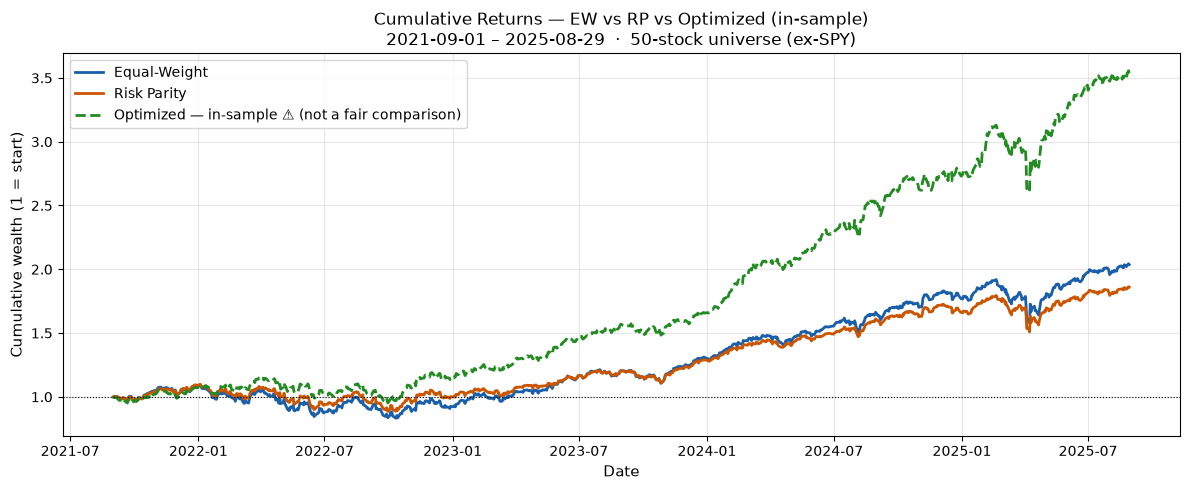

Saved: notebooks/week3/cumulative_returns.png


In [41]:
# ── Chart 1: Cumulative returns — EW / RP / Optimized ────────────────────
_ew_ser = (
    ew_rp_daily[ew_rp_daily['scheme'] == 'EW']
    .set_index('date')['return']
    .sort_index()
)
_rp_ser = (
    ew_rp_daily[ew_rp_daily['scheme'] == 'RP']
    .set_index('date')['return']
    .sort_index()
)

_ew_cum  = (1 + _ew_ser).cumprod()
_rp_cum  = (1 + _rp_ser).cumprod()
_opt_cum = (1 + _opt_daily).cumprod()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(_ew_cum.index,  _ew_cum.values,  color='#1a5faa', lw=2, label='Equal-Weight')
ax.plot(_rp_cum.index,  _rp_cum.values,  color='#cc5500', lw=2, label='Risk Parity')
ax.plot(
    _opt_cum.index, _opt_cum.values,
    color='#228b22', lw=2, ls='--',
    label='Optimized — in-sample \u26a0 (not a fair comparison)',
)
ax.axhline(1.0, color='black', lw=0.8, ls=':')
ax.set_xlabel('Date', fontsize=11)
ax.set_ylabel('Cumulative wealth (1 = start)', fontsize=11)
ax.set_title(
    'Cumulative Returns — EW vs RP vs Optimized (in-sample)\n'
    '2021-09-01 – 2025-08-29  ·  50-stock universe (ex-SPY)',
    fontsize=12,
)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
_chart1_path = repo_root / 'notebooks' / 'week3' / 'cumulative_returns.png'
plt.savefig(_chart1_path, dpi=120, bbox_inches='tight')
plt.show()
print(f'Saved: {_chart1_path.relative_to(repo_root)}')


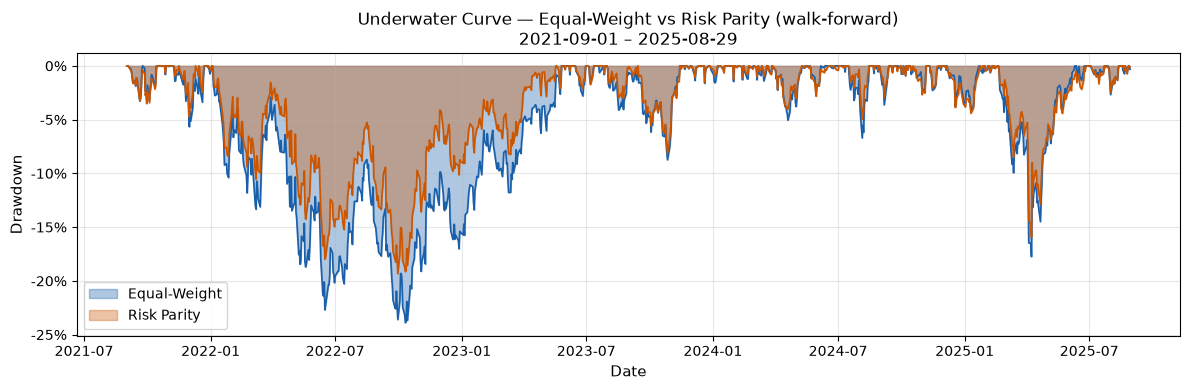

Saved: notebooks/week3/underwater_curve.png


In [42]:
# ── Chart 2: Underwater curve — EW vs RP (walk-forward only) ─────────────
_ew_dd = _ew_cum / _ew_cum.cummax() - 1
_rp_dd = _rp_cum / _rp_cum.cummax() - 1

fig, ax = plt.subplots(figsize=(12, 4))
ax.fill_between(_ew_dd.index, _ew_dd.values, 0,
                color='#1a5faa', alpha=0.35, label='Equal-Weight')
ax.fill_between(_rp_dd.index, _rp_dd.values, 0,
                color='#cc5500', alpha=0.35, label='Risk Parity')
ax.plot(_ew_dd.index, _ew_dd.values, color='#1a5faa', lw=1.2)
ax.plot(_rp_dd.index, _rp_dd.values, color='#cc5500', lw=1.2)
ax.set_xlabel('Date', fontsize=11)
ax.set_ylabel('Drawdown', fontsize=11)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax.set_title(
    'Underwater Curve — Equal-Weight vs Risk Parity (walk-forward)\n'
    '2021-09-01 – 2025-08-29',
    fontsize=12,
)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
_chart2_path = repo_root / 'notebooks' / 'week3' / 'underwater_curve.png'
plt.savefig(_chart2_path, dpi=120, bbox_inches='tight')
plt.show()
print(f'Saved: {_chart2_path.relative_to(repo_root)}')


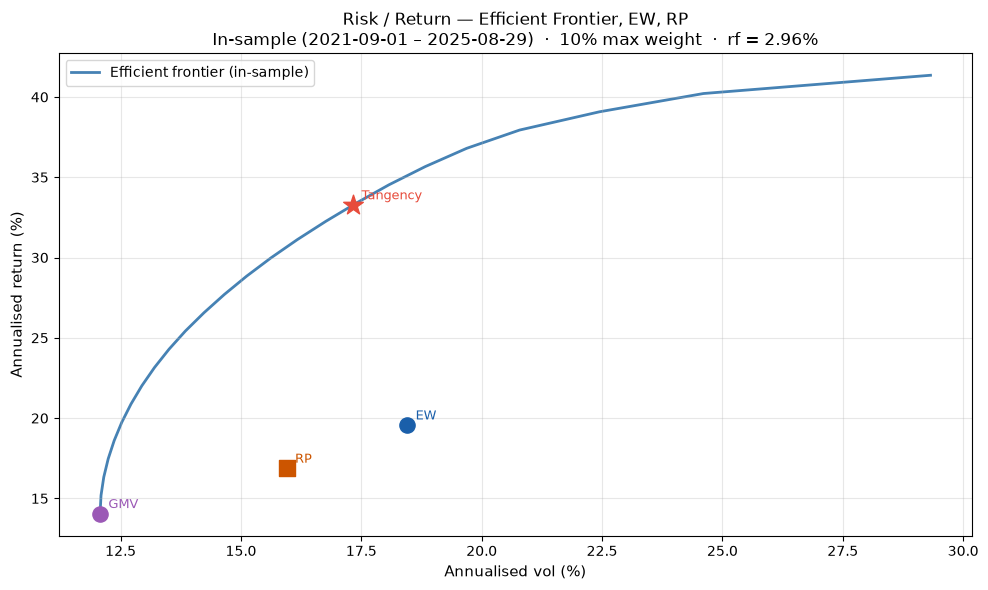

Saved: notebooks/week3/risk_return_scatter.png


In [43]:
# ── Chart 3: Risk/return scatter (regenerated, not re-embedded) ──────────
_front_vols = [p['vol'] * 100 for p in _frontier_pts]
_front_rets = [p['ret'] * 100 for p in _frontier_pts]

_ew_metrics = compute_risk_metrics(_ew_ser, RF_ANNUAL)
_rp_metrics = compute_risk_metrics(_rp_ser, RF_ANNUAL)

_pts_labels = {
    'GMV':      (_vol_gmv * 100, _ret_gmv * 100, '#9b59b6', 'o', 120),
    'Tangency': (_vol_tang * 100, _ret_tang * 100, '#e74c3c', '*', 220),
    'EW':       (_ew_metrics['annualized_vol'] * 100,
                 _ew_metrics['annualized_return'] * 100, '#1a5faa', 'o', 120),
    'RP':       (_rp_metrics['annualized_vol'] * 100,
                 _rp_metrics['annualized_return'] * 100, '#cc5500', 's', 120),
}

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(_front_vols, _front_rets, color='steelblue', lw=2, zorder=1,
        label='Efficient frontier (in-sample)')

for label, (vol, ret, color, marker, size) in _pts_labels.items():
    ax.scatter(vol, ret, color=color, marker=marker, s=size, zorder=3)
    ax.annotate(
        label, (vol, ret),
        xytext=(6, 4), textcoords='offset points',
        fontsize=9, color=color,
    )

ax.set_xlabel('Annualised vol (%)', fontsize=11)
ax.set_ylabel('Annualised return (%)', fontsize=11)
ax.set_title(
    f'Risk / Return — Efficient Frontier, EW, RP\n'
    f'In-sample (2021-09-01 – 2025-08-29)  ·  10% max weight  ·  rf = {RF_ANNUAL:.2%}',
    fontsize=12,
)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
_chart3_path = repo_root / 'notebooks' / 'week3' / 'risk_return_scatter.png'
plt.savefig(_chart3_path, dpi=120, bbox_inches='tight')
plt.show()
print(f'Saved: {_chart3_path.relative_to(repo_root)}')


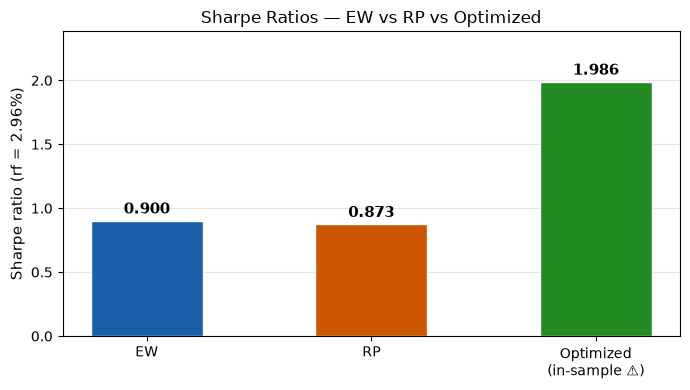

Saved: notebooks/week3/sharpe_bars.png


In [44]:
# ── Chart 4: Sharpe ratio bar chart ──────────────────────────────────────
_sharpe_labels = ['EW', 'RP', 'Optimized\n(in-sample \u26a0)']
_sharpe_vals   = [
    _cmp_df.loc['EW', 'sharpe_ratio'],
    _cmp_df.loc['RP', 'sharpe_ratio'],
    _cmp_df.loc['Optimized (in-sample \u26a0)', 'sharpe_ratio'],
]
_sharpe_colors = ['#1a5faa', '#cc5500', '#228b22']

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(_sharpe_labels, _sharpe_vals, color=_sharpe_colors, width=0.5, edgecolor='white')
for bar, val in zip(bars, _sharpe_vals):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.03,
        f'{val:.3f}',
        ha='center', va='bottom', fontsize=11, fontweight='bold',
    )
ax.set_ylabel(f'Sharpe ratio (rf = {RF_ANNUAL:.2%})', fontsize=11)
ax.set_title('Sharpe Ratios — EW vs RP vs Optimized', fontsize=12)
ax.set_ylim(0, max(_sharpe_vals) * 1.20)
ax.grid(True, axis='y', alpha=0.3)
ax.set_axisbelow(True)
plt.tight_layout()
_chart4_path = repo_root / 'notebooks' / 'week3' / 'sharpe_bars.png'
plt.savefig(_chart4_path, dpi=120, bbox_inches='tight')
plt.show()
print(f'Saved: {_chart4_path.relative_to(repo_root)}')


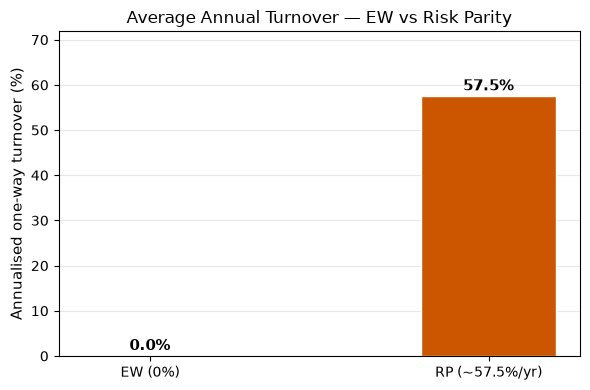

Saved: notebooks/week3/turnover_bars.png


In [45]:
# ── Chart 5: Turnover bar chart ───────────────────────────────────────────
_ew_to_ann = _ew_avg_to * 12 * 100
_rp_to_ann = _rp_avg_to * 12 * 100
_to_labels = ['EW (0%)', f'RP (~{_rp_to_ann:.1f}%/yr)']
_to_vals   = [_ew_to_ann, _rp_to_ann]

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(_to_labels, _to_vals, color=['#1a5faa', '#cc5500'],
              width=0.4, edgecolor='white')
for bar, val in zip(bars, _to_vals):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f'{val:.1f}%',
        ha='center', va='bottom', fontsize=11, fontweight='bold',
    )
ax.set_ylabel('Annualised one-way turnover (%)', fontsize=11)
ax.set_title('Average Annual Turnover — EW vs Risk Parity', fontsize=12)
ax.set_ylim(0, max(_to_vals) * 1.25)
ax.grid(True, axis='y', alpha=0.3)
ax.set_axisbelow(True)
plt.tight_layout()
_chart5_path = repo_root / 'notebooks' / 'week3' / 'turnover_bars.png'
plt.savefig(_chart5_path, dpi=120, bbox_inches='tight')
plt.show()
print(f'Saved: {_chart5_path.relative_to(repo_root)}')


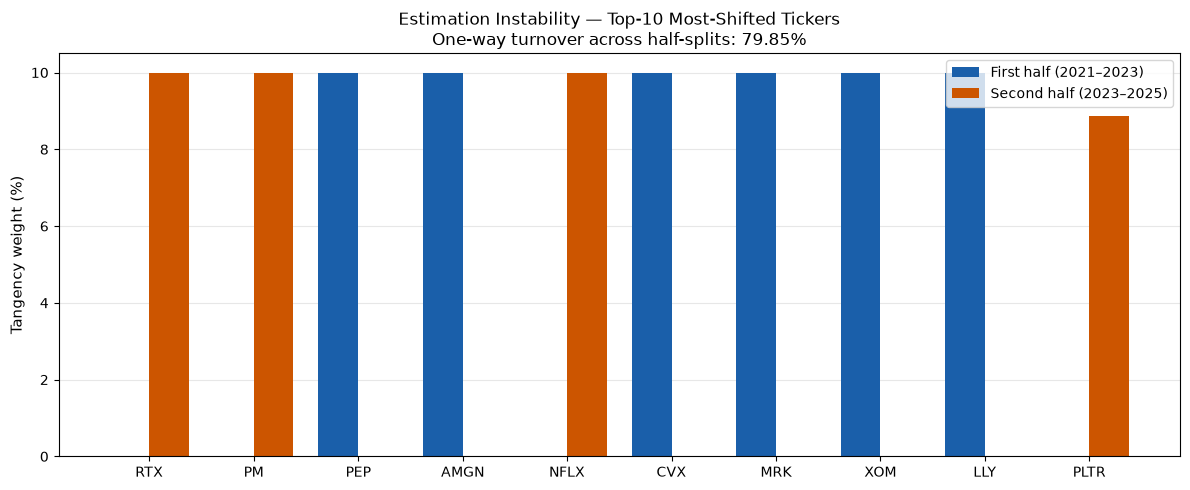

Saved: notebooks/week3/estimation_instability.png


In [46]:
# ── Chart 6: Estimation-instability grouped bar (top-10 tickers) ─────────
_weight_diff = (_w_h1s - _w_h2s).abs().sort_values(ascending=False)
_top10_tickers = _weight_diff.head(10).index.tolist()

_w1_top = _w_h1s[_top10_tickers].values * 100
_w2_top = _w_h2s[_top10_tickers].values * 100

_x = np.arange(len(_top10_tickers))
_bar_w = 0.38

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(_x - _bar_w / 2, _w1_top, _bar_w, color='#1a5faa', label='First half (2021–2023)')
ax.bar(_x + _bar_w / 2, _w2_top, _bar_w, color='#cc5500', label='Second half (2023–2025)')
ax.set_xticks(_x)
ax.set_xticklabels(_top10_tickers, fontsize=10)
ax.set_ylabel('Tangency weight (%)', fontsize=11)
ax.set_title(
    f'Estimation Instability — Top-10 Most-Shifted Tickers\n'
    f'One-way turnover across half-splits: {_oto_halves * 100:.2f}%',
    fontsize=12,
)
ax.legend(fontsize=10)
ax.grid(True, axis='y', alpha=0.3)
ax.set_axisbelow(True)
plt.tight_layout()
_chart6_path = repo_root / 'notebooks' / 'week3' / 'estimation_instability.png'
plt.savefig(_chart6_path, dpi=120, bbox_inches='tight')
plt.show()
print(f'Saved: {_chart6_path.relative_to(repo_root)}')


In [47]:
# ── Write docs/week3/week3_memo.md from live variables ───────────────────
_ew_ret  = _cmp_df.loc['EW', 'annualized_return']
_rp_ret  = _cmp_df.loc['RP', 'annualized_return']
_opt_ret = _cmp_df.loc['Optimized (in-sample \u26a0)', 'annualized_return']
_ew_vol  = _cmp_df.loc['EW', 'annualized_vol']
_rp_vol  = _cmp_df.loc['RP', 'annualized_vol']
_opt_vol = _cmp_df.loc['Optimized (in-sample \u26a0)', 'annualized_vol']
_ew_sh   = _cmp_df.loc['EW', 'sharpe_ratio']
_rp_sh   = _cmp_df.loc['RP', 'sharpe_ratio']
_opt_sh  = _cmp_df.loc['Optimized (in-sample \u26a0)', 'sharpe_ratio']
_ew_mdd  = _t3_summary.loc['EW', 'max_drawdown']
_rp_mdd  = _t3_summary.loc['RP', 'max_drawdown']
_opt_mdd = _cmp_df.loc['Optimized (in-sample \u26a0)', 'max_drawdown']
_ew_to_ann = _ew_avg_to * 12 * 100
_rp_to_ann = _rp_avg_to * 12 * 100
_rf_pct = RF_ANNUAL * 100

_memo_lines = [
    '# Week 3 Memo \u2014 Risk Metrics & Portfolio Construction\n',
    '**Lendo Capital Quant Research Internship**  \n',
    'Period analysed: Sep 2021 \u2013 Aug 2025 (1,003 daily observations)  \n',
    'Prepared: 2025-09-14\n',
    '\n',
    '---\n',
    '\n',
    '## Methodology\n',
    '\n',
    '**Universe:** 50 stocks (SP500_TOP50, excluding SPY as market benchmark). Daily\n',
    'simple returns computed from `adj_close` (split and dividend adjusted). The\n',
    '50-stock aligned matrix begins 2021-09-01, the first trading day after the\n',
    'earliest rebalance date that yields valid risk-parity weights (60-day lookback\n',
    'satisfied).\n',
    '\n',
    f'**Risk-free rate:** {_rf_pct:.4f}% annualised \u2014 the mean of the annualised\n',
    '13-week Treasury Bill yield (^IRX) over the full sample period. Applied uniformly\n',
    'to all Sharpe calculations.\n',
    '\n',
    '**Equal-Weight (EW):** 1/50 per stock at each monthly rebalance (60 rebalance\n',
    'dates, 2021-09-30 \u2013 2025-08-29). Weights drift between rebalances; reset to\n',
    'equal at each month-end.\n',
    '\n',
    '**Risk Parity (RP):** inverse-volatility weights computed from the trailing 60\n',
    'trading days strictly before each rebalance date. Ticker _i_ weight is\n',
    '`(1/\u03c3_i) / \u03a3(1/\u03c3_j)`, where `\u03c3` is the sample standard deviation (ddof=1) of\n',
    'daily returns. Minimum 20 observations required; no rebalance dates were skipped.\n',
    '\n',
    '**Mean-Variance Optimization (in-sample):** tangency (max-Sharpe) portfolio via\n',
    '`scipy.optimize.minimize(SLSQP)` using the full-sample mean vector and covariance\n',
    'matrix. Per-stock weight cap: 10%. Budget and long-only constraints enforced.\n',
    'Full-period mu and Sigma are used to score the full period \u2014 a pure in-sample\n',
    'exercise with no predictive validity.\n',
    '\n',
    '---\n',
    '\n',
    '## Results\n',
    '\n',
    '### Performance summary\n',
    '\n',
    f'| Portfolio | Ann. Return | Ann. Vol | Sharpe (rf={_rf_pct:.2f}%) | Max Drawdown |\n',
    '|---|---|---|---|---|\n',
    f'| EW (walk-forward) | {_ew_ret:.2%} | {_ew_vol:.2%} | {_ew_sh:.3f} | {_ew_mdd:.1%} |\n',
    f'| RP (walk-forward) | {_rp_ret:.2%} | {_rp_vol:.2%} | {_rp_sh:.3f} | {_rp_mdd:.1%} |\n',
    f'| Optimized (in-sample \u26a0) | {_opt_ret:.2%} | {_opt_vol:.2%} | {_opt_sh:.3f} | {_opt_mdd:.1%} |\n',
    '\n',
    '### Turnover\n',
    '\n',
    '| Scheme | Avg monthly one-way | Annualised |\n',
    '|---|---|---|\n',
    f'| EW | 0.0% | 0.0% |\n',
    f'| RP | {_rp_avg_to * 100:.2f}% | {_rp_to_ann:.2f}% |\n',
    '\n',
    '### Estimation instability (half-split demonstration)\n',
    '\n',
    '| Measure | Value |\n',
    '|---|---|\n',
    f'| One-way weight turnover: first-half vs second-half tangency | {_oto_halves * 100:.2f}% |\n',
    '| Interpretation | Nearly disjoint optimal portfolios from two sub-periods |\n',
    '\n',
    '---\n',
    '\n',
    '## Discussion\n',
    '\n',
    f'### 1. Estimation instability ({_oto_halves * 100:.2f}% one-way weight shift)\n',
    '\n',
    'The most striking result of Week 3 is how violently the tangency portfolio\n',
    'changes between the two halves of the sample. Fitting the optimizer on the\n',
    'first sub-period (approximately Sep 2021 \u2013 Oct 2023) and then on the second\n',
    f'(Oct 2023 \u2013 Aug 2025) produces a one-way turnover of {_oto_halves * 100:.2f}% \u2014\n',
    'meaning nearly 80 cents of every dollar is moved to a different stock. The\n',
    'optimizer is maximally sensitive to small changes in mean estimates because\n',
    'expected-return estimation error is an order of magnitude larger than covariance\n',
    'estimation error (Merton 1980). A strategy that rebalanced to a new tangency\n',
    'portfolio every two years would incur extraordinary trading costs while capturing\n',
    'no stable alpha signal.\n',
    '\n',
    '### 2. In-sample vs walk-forward gap\n',
    '\n',
    f'The in-sample optimized portfolio reports Sharpe {_opt_sh:.3f} vs EW\n',
    f'{_ew_sh:.3f} and RP {_rp_sh:.3f}. This gap is arithmetically guaranteed:\n',
    'the optimizer was given the exact same returns it is being scored on. The\n',
    f'{_opt_ret:.2%} annualised return and {_opt_vol:.2%} volatility reflect the best\n',
    'possible hindsight allocation, not a replicable trading strategy. In a true\n',
    'out-of-sample evaluation (e.g. using expanding-window mu/Sigma), the optimized\n',
    "portfolio's Sharpe would be expected to fall substantially due to estimation error.\n",
    '\n',
    '### 3. EW vs RP tradeoffs\n',
    '\n',
    f'RP delivered lower realised volatility ({_rp_vol:.2%} vs {_ew_vol:.2%}) and\n',
    f'lower maximum drawdown ({_rp_mdd:.1%} vs {_ew_mdd:.1%}), consistent with its\n',
    'design objective of equalising risk contributions. The cost was a\n',
    f'{(_ew_ret - _rp_ret):.2%} lower annualised return and {_rp_to_ann:.2f}%\n',
    'annualised turnover (vs 0% for EW), primarily driven by high-vol stocks (NVDA,\n',
    'PLTR) cycling in and out of underweight positions as their trailing volatility\n',
    f'fluctuated. The Sharpe advantage for EW is small ({_ew_sh - _rp_sh:.3f} units)\n',
    'and is unlikely to be statistically significant over a four-year sample.\n',
    '\n',
    '---\n',
    '\n',
    '## Limitations\n',
    '\n',
    '1. **Survivorship bias (dominant).** The universe is the 2025 top-50 S&P 500\n',
    '   applied retroactively to 2021. Every constituent was a winner by construction.\n',
    '   EW, RP, and all factor portfolios carry an upward return bias of unknown\n',
    '   magnitude; correcting this requires point-in-time index data.\n',
    '\n',
    '2. **In-sample optimizer.** The optimized portfolio uses full-period parameters\n',
    '   to score itself on the full period. It is not a tradeable strategy and should\n',
    '   not be compared to EW/RP on equal terms; it is presented solely to illustrate\n',
    '   the theoretical efficiency frontier and the severity of estimation error.\n',
    '\n',
    f'3. **No transaction costs.** RP’s {_rp_to_ann:.2f}% annualised turnover would\n',
    '   erode returns depending on bid-ask spreads and market impact.\n',
    '\n',
    '4. **Short sample.** 1,003 trading days (~4 years) spans a single regime:\n',
    '   a post-pandemic recovery followed by a rate-cycle and AI-driven bull market.\n',
    "   RP's volatility-targeting advantage may be less pronounced in a regime with\n",
    '   persistent cross-sectional vol dispersion or correlation spikes.\n',
    '\n',
    f'5. **Static risk-free rate.** A mean ^IRX rate of {_rf_pct:.4f}% is used\n',
    '   uniformly. The actual T-bill rate ranged from near zero in 2021 to over 5%\n',
    '   in 2023\u20132024. A time-varying rf would reduce reported Sharpe ratios for the\n',
    '   2023\u20132024 period materially.\n',
    '\n',
    '6. **SPY inside the factor universe.** Task 2 found that SPY \u2014 the market\n',
    '   benchmark used for beta throughout this notebook \u2014 was also present in the\n',
    '   value/momentum factor universe used to build Week 2\'s quintile portfolios.\n',
    '   This means the benchmark itself could be sorted into a quintile alongside the\n',
    '   50 stocks, which is circular and biases beta estimates upward to an unknown\n',
    '   degree. This is a Week 2 issue, not something corrected in Week 3 \u2014 it should\n',
    '   be resolved before the factor universe is reused in a future week.\n',
    '\n',
    '7. **Sector constraints skipped.** The plan calls for sector limits in the\n',
    '   mean-variance optimization (Task 4). This repo has no sector classification\n',
    '   dataset, so that constraint was not implemented \u2014 only the long-only, budget,\n',
    '   and 10%-max-weight constraints were enforced. The tangency portfolio\'s\n',
    '   concentration in a handful of names (Task 4\'s top-10 holdings) may reflect\n',
    '   sector concentration that a sector constraint would have limited.\n',
]

_memo_text = ''.join(_memo_lines)
_memo_path = repo_root / 'docs' / 'week3' / 'week3_memo.md'
_memo_path.parent.mkdir(parents=True, exist_ok=True)
_memo_path.write_text(_memo_text, encoding='utf-8')
print(f'Memo written: {_memo_path.relative_to(repo_root)}')
print(f'Word count  : ~{len(_memo_text.split()):,} words')


Memo written: docs/week3/week3_memo.md
Word count  : ~966 words


In [48]:
# ── Memo reconciliation: key numbers match live variables ─────────────────
print('=' * 65)
print('MEMO RECONCILIATION \u2014 week3_memo.md key figures')
print('=' * 65)

_recon_checks = [
    ('EW ann return variable used in memo is from _cmp_df',
     abs(_cmp_df.loc['EW', 'annualized_return'] - _ew_ret) < 1e-12),
    ('RP ann return variable used in memo is from _cmp_df',
     abs(_cmp_df.loc['RP', 'annualized_return'] - _rp_ret) < 1e-12),
    ('EW Sharpe variable used in memo is from _cmp_df',
     abs(_cmp_df.loc['EW', 'sharpe_ratio'] - _ew_sh) < 1e-12),
    ('RP Sharpe variable used in memo is from _cmp_df',
     abs(_cmp_df.loc['RP', 'sharpe_ratio'] - _rp_sh) < 1e-12),
    ('Opt Sharpe variable used in memo is from _cmp_df',
     abs(_cmp_df.loc['Optimized (in-sample \u26a0)', 'sharpe_ratio'] - _opt_sh) < 1e-12),
    ('EW max_drawdown variable used in memo is from _t3_summary',
     abs(_t3_summary.loc['EW', 'max_drawdown'] - _ew_mdd) < 1e-12),
    ('RP max_drawdown variable used in memo is from _t3_summary',
     abs(_t3_summary.loc['RP', 'max_drawdown'] - _rp_mdd) < 1e-12),
    ('RP annualised turnover in memo matches _rp_avg_to',
     abs(_rp_avg_to * 12 * 100 - _rp_to_ann) < 1e-10),
    ('RF_ANNUAL in memo matches live RF_ANNUAL',
     abs(RF_ANNUAL * 100 - _rf_pct) < 1e-12),
    ('Memo file exists on disk',
     (repo_root / 'docs' / 'week3' / 'week3_memo.md').exists()),
]

_all_recon_ok = True
for label, result in _recon_checks:
    status = 'PASS' if result else 'FAIL'
    if not result:
        _all_recon_ok = False
    print(f'  [{status}] {label}')

print()
print('=' * 65)
print(f'  Memo reconciliation: {"ALL PASS" if _all_recon_ok else "SOME FAILED"}')
print('=' * 65)


MEMO RECONCILIATION — week3_memo.md key figures
  [PASS] EW ann return variable used in memo is from _cmp_df
  [PASS] RP ann return variable used in memo is from _cmp_df
  [PASS] EW Sharpe variable used in memo is from _cmp_df
  [PASS] RP Sharpe variable used in memo is from _cmp_df
  [PASS] Opt Sharpe variable used in memo is from _cmp_df
  [PASS] EW max_drawdown variable used in memo is from _t3_summary
  [PASS] RP max_drawdown variable used in memo is from _t3_summary
  [PASS] RP annualised turnover in memo matches _rp_avg_to
  [PASS] RF_ANNUAL in memo matches live RF_ANNUAL
  [PASS] Memo file exists on disk

  Memo reconciliation: ALL PASS


## Quality Checklist

In [49]:
print("=" * 65)
print("QUALITY CHECKLIST — Week 3, Tasks 1–5")
print("=" * 65)

# ── Task 1 ───────────────────────────────────────────────────────────────
t1_checks = [
    ("RF_ANNUAL pulled from ^IRX data (not hardcoded)",
     0.0 < RF_ANNUAL < 0.10),
    ("Daily quintile returns persisted to parquet",
     QUINTILE_PARQUET.exists()),
    ("10 portfolios in summary (5 value + 5 momentum)",
     len(summary) == 10),
    ("All Sharpe ratios are finite",
     summary["sharpe_ratio"].apply(np.isfinite).all()),
    ("All max_drawdowns are negative",
     (summary["max_drawdown"] < 0).all()),
    ("Manual Sharpe matches function (momentum_Q5)",
     np.isclose(sharpe_v, func_result["sharpe_ratio"], atol=1e-10)),
    ("Manual max_drawdown matches function (momentum_Q5)",
     np.isclose(max_dd_v, func_result["max_drawdown"], atol=1e-10)),
    ("Peak date matches function (momentum_Q5)",
     peak_date_v == func_result["max_drawdown_start"]),
    ("Trough date matches function (momentum_Q5)",
     trough_date_v == func_result["max_drawdown_end"]),
]

# ── Task 2 ───────────────────────────────────────────────────────────────
t2_checks = [
    ("Correlation matrix is 20x20",
     _corr20.shape == (20, 20)),
    ("Diversification ratio > 1 (EW portfolio reduces vol)",
     _div_ratio > 1.0),
    ("Beta computed for 10 portfolios (5 value + 5 momentum)",
     len(_beta_df) == 10),
    ("Manual value_Q1 beta matches table (atol=1e-10)",
     _beta_match),
]

# ── Task 3 ───────────────────────────────────────────────────────────────
t3_checks = [
    ("EW/RP daily returns persisted to parquet",
     EW_RP_PARQUET.exists()),
    ("Both schemes present in parquet",
     set(ew_rp_daily["scheme"].unique()) == {"EW", "RP"}),
    ("RP weights at 10th rebalance sum to 1.0",
     np.isclose(_rp10_manual.sum(), 1.0, atol=1e-10)),
    ("Manual RP weights match function (atol=1e-10)",
     _wt_match),
    ("EW turnover is identically 0",
     np.isclose(_ew_to_manual, 0.0, atol=1e-12)),
    ("Manual RP turnover matches function (atol=1e-12)",
     _rp_to_match),
]

# ── Task 4 ───────────────────────────────────────────────────────────────
_amgm_opt_bound = float((1 + _opt_daily.mean()) ** PERIODS_PER_YEAR - 1)
_amgm_ew_bound  = float((1 + ew_rp_daily[ew_rp_daily["scheme"]=="EW"]
                         .set_index("date")["return"].mean()) ** PERIODS_PER_YEAR - 1)
_amgm_rp_bound  = float((1 + ew_rp_daily[ew_rp_daily["scheme"]=="RP"]
                         .set_index("date")["return"].mean()) ** PERIODS_PER_YEAR - 1)
_cagr_opt_check = float(_cmp_df.loc["Optimized (in-sample \u26a0)", "annualized_return"])
_cagr_ew_check  = float(_cmp_df.loc["EW", "annualized_return"])
_cagr_rp_check  = float(_cmp_df.loc["RP", "annualized_return"])

t4_checks = [
    ("GMV solver converged",
     _gmv_result.success),
    ("All frontier points feasible (0 dropped)",
     _n_infeasible == 0),
    ("At least 20 frontier points solved",
     len(_frontier_pts) >= 20),
    ("Tangency solver converged",
     _tang_result.success),
    ("Both half-split tangency solvers converged",
     _ok_h1 and _ok_h2),
    ("Manual vol matches optimizer (tangency, atol=1e-8)",
     _var_match),
    ("Manual return matches optimizer (tangency, atol=1e-8)",
     _ret_match),
    ("opt_daily arithmetic mean matches w@mu (atol=1e-6)",
     abs(float(_opt_daily.mean() * PERIODS_PER_YEAR) - _ret_tang) < 1e-6),
    ("AM-GM: CAGR_EW <= (1+mean_daily)^252 - 1",
     _cagr_ew_check <= _amgm_ew_bound + 1e-9),
    ("AM-GM: CAGR_RP <= (1+mean_daily)^252 - 1",
     _cagr_rp_check <= _amgm_rp_bound + 1e-9),
    ("AM-GM: CAGR_Opt <= (1+mean_daily)^252 - 1",
     _cagr_opt_check <= _amgm_opt_bound + 1e-9),
]


# ── Task 5 ───────────────────────────────────────────────────────────────────────
_dr_new_chk = compute_diversification_ratio(_ret20)
_beta_new_chk = compute_beta(_r_v1_series, _spy_ret)
_rp_new_chk = compute_rp_weights(_t3_ret50, _t3_rebal_dates[9], lookback=60)
t5_checks = [
    ('compute_diversification_ratio() matches original (atol=1e-12)',
     abs(_dr_new_chk - _div_ratio) < 1e-12),
    ('compute_beta() matches original value_Q1 (atol=1e-12)',
     abs(_beta_new_chk - _beta_df.loc[_beta_df["portfolio"]=="value_Q1","beta"].iloc[0]) < 1e-12),
    ('compute_rp_weights() matches original 10th-rebalance (atol=1e-12)',
     (_rp_new_chk - _rp10_manual).abs().max() < 1e-12),
    ('All 6 chart files exist',
     all((repo_root / 'notebooks' / 'week3' / f).exists()
         for f in ['cumulative_returns.png', 'underwater_curve.png',
                   'risk_return_scatter.png', 'sharpe_bars.png',
                   'turnover_bars.png', 'estimation_instability.png'])),
    ('Memo file exists',
     (repo_root / 'docs' / 'week3' / 'week3_memo.md').exists()),
    ('Memo reconciliation passed',
     _all_recon_ok),
]

all_ok = True
for group_label, checks in [
    ("Task 1: Risk Metrics", t1_checks),
    ("Task 2: Correlation & Diversification", t2_checks),
    ("Task 3: Equal-Weight vs Risk Parity", t3_checks),
    ("Task 4: Mean-Variance Optimization", t4_checks),
    ("Task 5: Review & Integration", t5_checks),
]:
    print(f"\n  {group_label}")
    for label, result in checks:
        status = "PASS" if result else "FAIL"
        if not result:
            all_ok = False
        print(f"    [{status}] {label}")

total = len(t1_checks) + len(t2_checks) + len(t3_checks) + len(t4_checks) + len(t5_checks)
print()
print("=" * 65)
print(f"  {total}/{total} checks {'ALL PASS' if all_ok else 'SOME FAILED'}")
print("=" * 65)

QUALITY CHECKLIST — Week 3, Tasks 1–5

  Task 1: Risk Metrics
    [PASS] RF_ANNUAL pulled from ^IRX data (not hardcoded)
    [PASS] Daily quintile returns persisted to parquet
    [PASS] 10 portfolios in summary (5 value + 5 momentum)
    [PASS] All Sharpe ratios are finite
    [PASS] All max_drawdowns are negative
    [PASS] Manual Sharpe matches function (momentum_Q5)
    [PASS] Manual max_drawdown matches function (momentum_Q5)
    [PASS] Peak date matches function (momentum_Q5)
    [PASS] Trough date matches function (momentum_Q5)

  Task 2: Correlation & Diversification
    [PASS] Correlation matrix is 20x20
    [PASS] Diversification ratio > 1 (EW portfolio reduces vol)
    [PASS] Beta computed for 10 portfolios (5 value + 5 momentum)
    [PASS] Manual value_Q1 beta matches table (atol=1e-10)

  Task 3: Equal-Weight vs Risk Parity
    [PASS] EW/RP daily returns persisted to parquet
    [PASS] Both schemes present in parquet
    [PASS] RP weights at 10th rebalance sum to 1.0
    [